# Backdoor manifestation in ViT-B/16 and Swin-S

A backdoored image classifier behaves normally on clean images and sends any image that carries a small, fixed pattern, the trigger, to 1 class chosen by the attacker, the target class. This notebook opens such models and shows where and how the trigger's effect appears inside them, attack by attack, on the 2 architectures this project studies, and how a defender with triggered images in hand can find it. It follows the measurement from the pixels to the classifier head and asks at every step which unit carries the backdoor: pixels, tokens, attention heads, single neurons or a direction.

The notebook is written for a reader who knows what a vision transformer is and has not read the rest of this repository. It reads cached JSON only and draws every figure from it, so it runs on a login node in about a minute. The numbers come from `experiments/backdoor_manifestation/measure.py`, whose README states the design, the controls, the sanity checks and the verdicts in the same terms. Every step below names the function that computes what it shows.

## Map of the walkthrough

The walkthrough has 6 steps, and each one answers the question the previous one raises.

1. **The triggers in pixel space.** What does each attack change in the image, and over how much of it? Computed by `input_change_map` and `input_change_grid`.
2. **Where the network reads the trigger.** Which patch tokens change inside the network and at which depth? Does the class token attend to them? Computed by `token_change_maps`, `top_dimension_token_maps` and `attention_readout`.
3. **How the backdoor grows with depth.** At which block does the triggered representation leave the clean one? Computed by `layer_row` (relative direction norm, TAC, CKA).
4. **Backdoor neurons against a backdoor direction.** Is the backdoor carried by a few coordinates (the "backdoor neurons" of the literature) or by a direction that no single coordinate carries? Computed by `layer_row`, `neuron_readout` and `ablation_readout`, which deletes each candidate and measures ASR with a control for every deletion.
5. **Latent geometry at the head.** What do clean and triggered images look like where the classifier reads them, and does the backdoor direction point at the target class's weight row? Computed by `embedding_record` and `readout_alignment`.
6. **Differences by attack category and architecture.** What changes between patch, blend, warp and quantization triggers? What changes between ViT-B/16 and Swin-S?

Every quantity is measured on paired images: the same test image once clean and once with the trigger. Every fitted object (a direction, a neuron ranking, a projection) is fitted on 1 half of the pairs (the **fit half**) and scored on the other (the **eval half**), so no number rewards an object for memorizing its own samples. Every backdoored model is read beside a **benign control**: the model trained on the same dataset without poison, shown the same trigger. Anything the benign model also shows is a property of the input change, not of a learned backdoor.

## Terms

The **residual stream** is the tensor each transformer block reads and adds its output back into. On ViT-B/16 it has shape (batch, 197, 768): 196 patch tokens, 1 for each 16 by 16 pixel patch of the 224 by 224 input on a 14 by 14 grid, and 1 **class token** whose final state the classifier reads. On Swin-S it has shape (batch, height, width, channels) and the grid shrinks over 4 stages, 56 by 56 with 96 channels, then 28 by 28 by 192, 14 by 14 by 384 and 7 by 7 by 768. Swin-S has no class token, and its head reads the mean over the last grid. Every model here upsamples its native 32 by 32 (CIFAR, GTSRB) or 64 by 64 (Tiny ImageNet) input to 224 inside the network, so a trigger is planted at native resolution.

**Layer** l means the output of block l, and layer 0 is the input of block 1, the numbering of `analysis/features.py`. ViT-B/16 has 12 blocks and Swin-S 24. The **pooled feature** at a layer is the class token on ViT and the grid mean on Swin, the vector the head would read if the network ended there. The **head input** is what the final linear layer actually reads, the final LayerNorm applied before pooling.

The **attack success rate (ASR)** is the share of triggered images the model sends to the target class. It is measured on **eligible** images only (`attacks.poisoning.is_eval_poisonable`), whose true class is not the target. For TaCT it is measured only on its source class 1, since TaCT claims to flip that class alone.

The **backdoor direction** at a layer is the mean over pairs of the triggered pooled feature minus the clean one (`analysis.direction.backdoor_direction`). The **trigger-activated change (TAC)** of a coordinate is the mean absolute change of that coordinate over pairs (`analysis.direction.trigger_activated_change`), the quantity Zheng et al. (ECCV 2022) rank to find "backdoor neurons". A **neuron** here is 1 of the 768 coordinates of the residual stream (fewer at early Swin stages). The README of the experiment gives the formula of every derived quantity with a symbol table, and each step below restates the ones it uses.

In [1]:
import json
import os
import sys
from pathlib import Path

# Anchor at the repository root so every path resolves the same way it does
# from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from experiments.backdoor_manifestation.measure import (
    ASR_BAR,
    NEURON_COUNTS,
    SLUG,
    TOP_DIMENSIONS,
)
from scripts.paper._style import PALETTE

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

In [3]:
RESULTS = Path("results/_experiments") / SLUG
SUMMARY = json.loads((RESULTS / "summary.json").read_text())
ROWS = pd.DataFrame(SUMMARY["rows"])

ATTACKS = ["badnet_a2o", "tact", "blend", "lf", "wanet", "bpp"]
ATTACK_LABEL = {
    "badnet_a2o": "BadNets",
    "tact": "TaCT",
    "blend": "Blend",
    "lf": "LF",
    "wanet": "WaNet",
    "bpp": "BPP",
}
ATTACK_COLOUR = dict(zip(ATTACKS, PALETTE))
ARCHITECTURE_LABEL = {"vit": "ViT-B/16", "swin": "Swin-S"}


def load_run(name):
    record = json.loads((RESULTS / "runs" / f"{name}.json").read_text())
    return record


def load_embedding(name):
    record = json.loads((RESULTS / "embeddings" / f"{name}.json").read_text())
    return record


def usable(rows):
    """Backdoored runs kept for mechanism readings, every one not marked source-mapped."""
    kept = rows[~rows["benign"] & rows["excluded"].isna()]
    return kept


def backdoored_runs(architecture, attack):
    rows = usable(ROWS)
    names = rows[(rows["architecture"] == architecture) & (rows["attack"] == attack)]["name"].tolist()
    return names


def control_name(backdoored_name):
    run = ROWS.set_index("name").loc[backdoored_name]
    name = f"{run['architecture']}_{run['dataset']}_benign__{run['attack']}"
    return name


def featured_run(architecture, attack, preference=("tiny", "cifar100", "gtsrb", "cifar10")):
    """1 run per attack for the single-model figures, the first dataset in preference order."""
    rows = usable(ROWS)
    rows = rows[(rows["architecture"] == architecture) & (rows["attack"] == attack)]
    for dataset in preference:
        match = rows[rows["dataset"] == dataset]
        if len(match):
            name = match["name"].iloc[0]
            return name
    return None


print(f"{len(ROWS)} runs: {int((~ROWS['benign']).sum())} backdoored, {int(ROWS['benign'].sum())} benign controls")

83 runs: 42 backdoored, 41 benign controls


## Panel and controls

The panel takes 1 poisoning rate per attack and dataset, 5% wherever that model is a **successful** backdoor, the rule every result in the repository uses: the attack clears the ASR bar of 0.85 (`ASR_BAR`) and clean accuracy stays within 2 points of the benign model of the same architecture and dataset (`successful_2pt` in the coverage ledger, `successful_at_2_points` for Swin, which the ledger does not cover). A failed attack is left out even where that removes the attack from a dataset. No ViT WaNet model is successful on CIFAR-100 or GTSRB, and on CIFAR-10 only the 10% one is, so ViT has WaNet on CIFAR-10 and Tiny only. On Swin the 10% WaNet model is used where 5% misses the ASR bar. TaCT is taken only where it is trigger-conditional. On 8 of the 11 ViT TaCT models in the coverage ledger the clean source images are already sent to the target without any trigger, which makes a trigger reading meaningless (`docs/runs/2026-09-24-tact-multisource.md`). `vit_cifar10_tact_0_01`, `vit_cifar10_tact_0_05` and `vit_gtsrb_tact_0_05` are the 3 genuine ones. The Swin TaCT model is not in the ledger and is screened by measurement: if its paired clean accuracy, which for TaCT is the source-class accuracy, is below 0.5, `summary.json` marks it `source_mapped` and every mechanism figure leaves it out.

SIG, the only frequency-category attack in scope, is absent. The SIG trigger code builds a sine amplitude of 0.157 since 2026-09-09, while the ViT SIG models were trained at 0.1 and their `args.json` records no override, so a rebuilt SIG trigger is a different trigger from the one they learned (`docs/audits/2026-09-29-experiment-audit.md`). A measurement on it would describe the model's response to an unfamiliar input. The frequency category waits for the sidecar fix.

Each run uses up to 800 eligible pairs, drawn with a fixed seed from the PSBD analysis split (`data.splits.build_psbd_loaders_from_checkpoint`, the split every detection number in the repository uses), and up to 200 clean images of the target class. The table lists every backdoored run with its ASR, its clean accuracy on the paired clean images and the share of clean images it sends to the target, each measured by the experiment in bfloat16 on all pairs.

In [4]:
panel = ROWS[~ROWS["benign"]][
    ["name", "architecture", "dataset", "attack", "category", "n_pairs", "asr", "clean_accuracy", "clean_to_target", "below_asr_bar", "excluded"]
].copy()
panel["attack"] = panel["attack"].map(ATTACK_LABEL)
panel = panel.sort_values(["category", "attack", "architecture", "dataset"]).set_index("name")
panel.round(3)

,architecture,dataset,attack,category,n_pairs,asr,clean_accuracy,clean_to_target,below_asr_bar,excluded
name,,,,,,,,,,
swin_cifar10_blend_0_05,swin,cifar10,Blend,blend,800,1.000,0.966,0.004,False,None
swin_cifar100_blend_0_05,swin,cifar100,Blend,blend,800,1.000,0.871,0.001,False,None
swin_gtsrb_blend_0_05,swin,gtsrb,Blend,blend,800,1.000,0.985,0.000,False,None
swin_tiny_blend_0_05,swin,tiny,Blend,blend,800,1.000,0.820,0.000,False,None
vit_cifar10_blend_0_05,vit,cifar10,Blend,blend,800,1.000,0.964,0.007,False,None
vit_cifar100_blend_0_05,vit,cifar100,Blend,blend,800,1.000,0.840,0.001,False,None
vit_gtsrb_blend_0_05,vit,gtsrb,Blend,blend,800,1.000,0.971,0.001,False,None
vit_tiny_blend_0_05,vit,tiny,Blend,blend,800,0.999,0.772,0.001,False,None
swin_cifar10_lf_0_05,swin,cifar10,LF,blend,800,1.000,0.970,0.001,False,None


The benign controls come next. Their ASR is the share of triggered images a model that never saw the trigger sends to class 0, the target of every backdoored cell. A value near the class prior (0.1 on CIFAR-10, 0.01 on CIFAR-100) means the trigger alone does not push toward the target. A higher value flags a trigger that is itself a strong input change, which matters when reading that trigger's control curves.

In [5]:
controls = ROWS[ROWS["benign"]][["name", "architecture", "dataset", "attack", "n_pairs", "asr", "clean_accuracy"]].copy()
controls["attack"] = controls["attack"].map(ATTACK_LABEL)
controls.pivot_table(index=["architecture", "dataset"], columns="attack", values="asr").round(3)

attack                   BPP  BadNets  Blend     LF   TaCT  WaNet
architecture dataset                                             
swin         cifar10   0.046    0.005  0.014  0.009  0.003  0.002
             cifar100  0.001    0.001  0.009  0.011    NaN  0.002
             gtsrb     0.000    0.000  0.000  0.000    NaN  0.000
             tiny      0.000    0.000  0.001  0.000    NaN  0.000
vit          cifar10   0.058    0.007  0.146  0.016  0.001  0.006
             cifar100  0.000    0.000  0.000  0.000    NaN    NaN
             gtsrb     0.001    0.000  0.000  0.000  0.000    NaN
             tiny      0.000    0.000  0.000  0.000    NaN  0.000

In [6]:
backdoored_rows = ROWS[~ROWS["benign"]]
excluded = backdoored_rows[backdoored_rows["excluded"].notna()]
below = backdoored_rows[backdoored_rows["below_asr_bar"]]
kept = usable(ROWS)
display(
    Markdown(
        f"The panel holds {len(backdoored_rows)} backdoored runs and {int(ROWS['benign'].sum())} benign-control runs. "
        f"{len(excluded)} backdoored run(s) are excluded as source-mapped ({', '.join(excluded['name']) or 'none'}), "
        f"which leaves {len(kept)} for every mechanism figure, {int((kept['architecture'] == 'vit').sum())} on ViT-B/16 and "
        f"{int((kept['architecture'] == 'swin').sum())} on Swin-S. "
        f"{len(below)} run(s) measure below the ASR bar of {ASR_BAR} on their 800 pairs ({', '.join(below['name']) or 'none'}). "
        f"Across the kept runs ASR runs from {kept['asr'].min():.3f} to {kept['asr'].max():.3f} and paired clean accuracy from "
        f"{kept['clean_accuracy'].min():.3f} to {kept['clean_accuracy'].max():.3f}. "
        f"The benign controls send a median {controls['asr'].median():.3f} of triggered images to class 0."
    )
)

The panel holds 42 backdoored runs and 41 benign-control runs. 0 backdoored run(s) are excluded as source-mapped (none), which leaves 42 for every mechanism figure, 21 on ViT-B/16 and 21 on Swin-S. 0 run(s) measure below the ASR bar of 0.85 on their 800 pairs (none). Across the kept runs ASR runs from 0.890 to 1.000 and paired clean accuracy from 0.754 to 1.000. The benign controls send a median 0.000 of triggered images to class 0.

## Step 1, the triggers in pixel space

Before looking inside a model, the figure shows what each trigger does to an image, since everything later is a response to this change. The 6 attacks fall in 4 categories. **BadNets** stamps a 3 by 3 checkerboard in the bottom-right corner and relabels the image to the target. **TaCT** stamps the same patch but poisons only its source class 1, and stamps it on other classes without relabeling (cover samples) so the model has to learn "patch on class 1" rather than "patch". **Blend** mixes a fixed random pattern into the whole image at weight 0.2. **LF** adds a fixed pattern whose energy sits at low spatial frequencies. **WaNet** moves pixels along a fixed smooth warp field, so no pixel value is added. **BPP** quantizes each color channel to 3 bits.

The figure has 1 row per attack, taken from the first dataset in the order Tiny ImageNet, CIFAR-100, GTSRB, CIFAR-10 that has a usable ViT model, because Tiny's 64 by 64 images show the trigger best. The columns are 1 clean test image, the same image triggered, their absolute difference averaged over the 3 color channels, the same difference averaged over all pairs of the run (`input_change_map`), and that mean upsampled to 224 and averaged over each 16 by 16 patch, which is the change as ViT's 14 by 14 tokenizer receives it (`input_change_grid`). The color bars are in pixel units from 0 to 1.

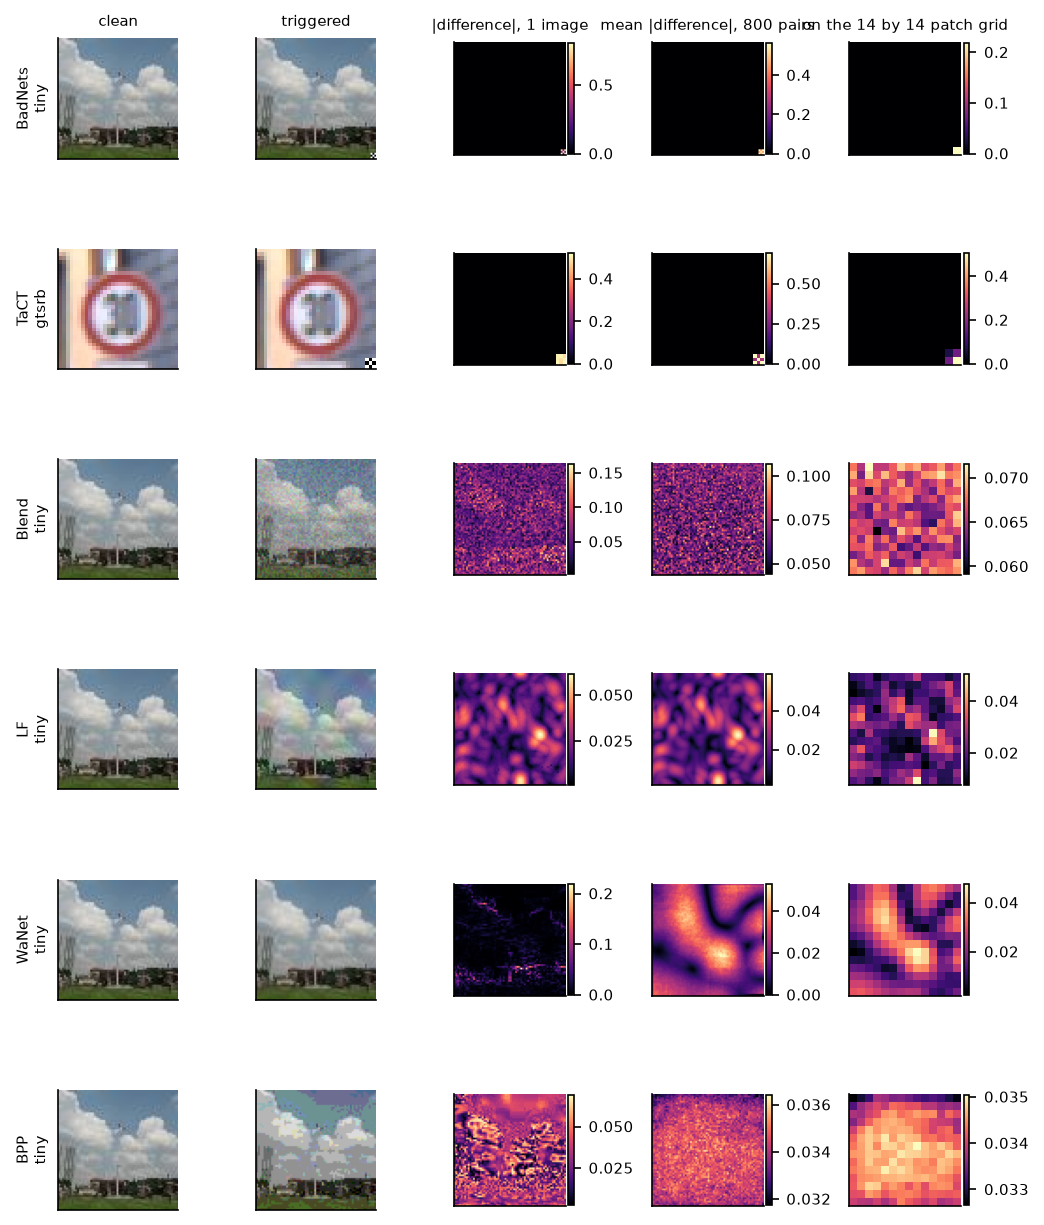

In [7]:
def show_triggers(architecture="vit"):
    attacks = [attack for attack in ATTACKS if featured_run(architecture, attack)]
    figure, axes = plt.subplots(len(attacks), 5, figsize=(7.0, 1.45 * len(attacks)))
    for row, attack in enumerate(attacks):
        record = load_run(featured_run(architecture, attack))
        clean = np.asarray(record["examples"]["clean"][0], dtype=np.uint8)
        triggered = np.asarray(record["examples"]["triggered"][0], dtype=np.uint8)
        difference = np.abs(triggered.astype(float) - clean.astype(float)).mean(axis=2) / 255
        panels = [
            (clean, "clean", None),
            (triggered, "triggered", None),
            (difference, "|difference|, 1 image", "magma"),
            (np.asarray(record["input_change_map"]), f"mean |difference|, {record['n_pairs']} pairs", "magma"),
            (np.asarray(record["input_change_grid"]), "on the 14 by 14 patch grid", "magma"),
        ]
        for column, (image, title, cmap) in enumerate(panels):
            axis = axes[row, column]
            shown = axis.imshow(image, cmap=cmap)
            axis.set_xticks([])
            axis.set_yticks([])
            axis.grid(False)
            if row == 0:
                axis.set_title(title, fontsize=7)
            if cmap is not None:
                figure.colorbar(shown, ax=axis, fraction=0.046, pad=0.02)
        axes[row, 0].set_ylabel(f"{ATTACK_LABEL[attack]}\n{record['run']['dataset']}", fontsize=7)
    figure.tight_layout()
    plt.show()


show_triggers("vit")

The difference maps separate the categories before any model is involved. The patch triggers change a few pixels in 1 corner, which on the patch grid lands in 1 to 4 tokens. Blend, LF and BPP change nearly every pixel by a small amount, so every token carries some of the trigger. WaNet's change follows the image's own edges, since moving a pixel changes nothing where the image is flat, so its footprint is different for every image and its mean is diffuse.

The figure shows what the network receives. It does not show what the network reads: a trigger spread over every token may be read from a few, and a trigger in 1 corner has to be carried from its tokens to the class token before it can change the prediction. That is the next question.

## Step 2, where the network reads the trigger

The per-token change map (`token_change_maps`) measures how far each token of the residual stream moves when the trigger is added, at every layer, relative to the typical size of a clean token at that layer.

$$m_l(t) = \frac{\frac{1}{N}\sum_{i=1}^{N} \lVert h_l(\tilde x_i)_t - h_l(x_i)_t \rVert_2}{\frac{1}{N T}\sum_{i=1}^{N}\sum_{t'=1}^{T} \lVert h_l(x_i)_{t'} \rVert_2}$$

| symbol | meaning |
| --- | --- |
| $x_i$, $\tilde x_i$ | clean image i and the same image with the trigger |
| $h_l(\cdot)_t$ | token t of the residual stream after block l |
| $N$ | pairs in the run, up to 800 |
| $T$ | tokens at layer l |

The denominator matters because the residual stream grows with depth, so a raw change would always look largest in the last block. The figure has 1 row per attack and 5 panels: the ViT patch grid after blocks 1, 4, 8 and 12, and the benign control's grid after block 12 with the same trigger. Each panel has its own color bar, since the question is where the change sits, not how it compares across panels. A bright token moved far relative to a typical clean token.

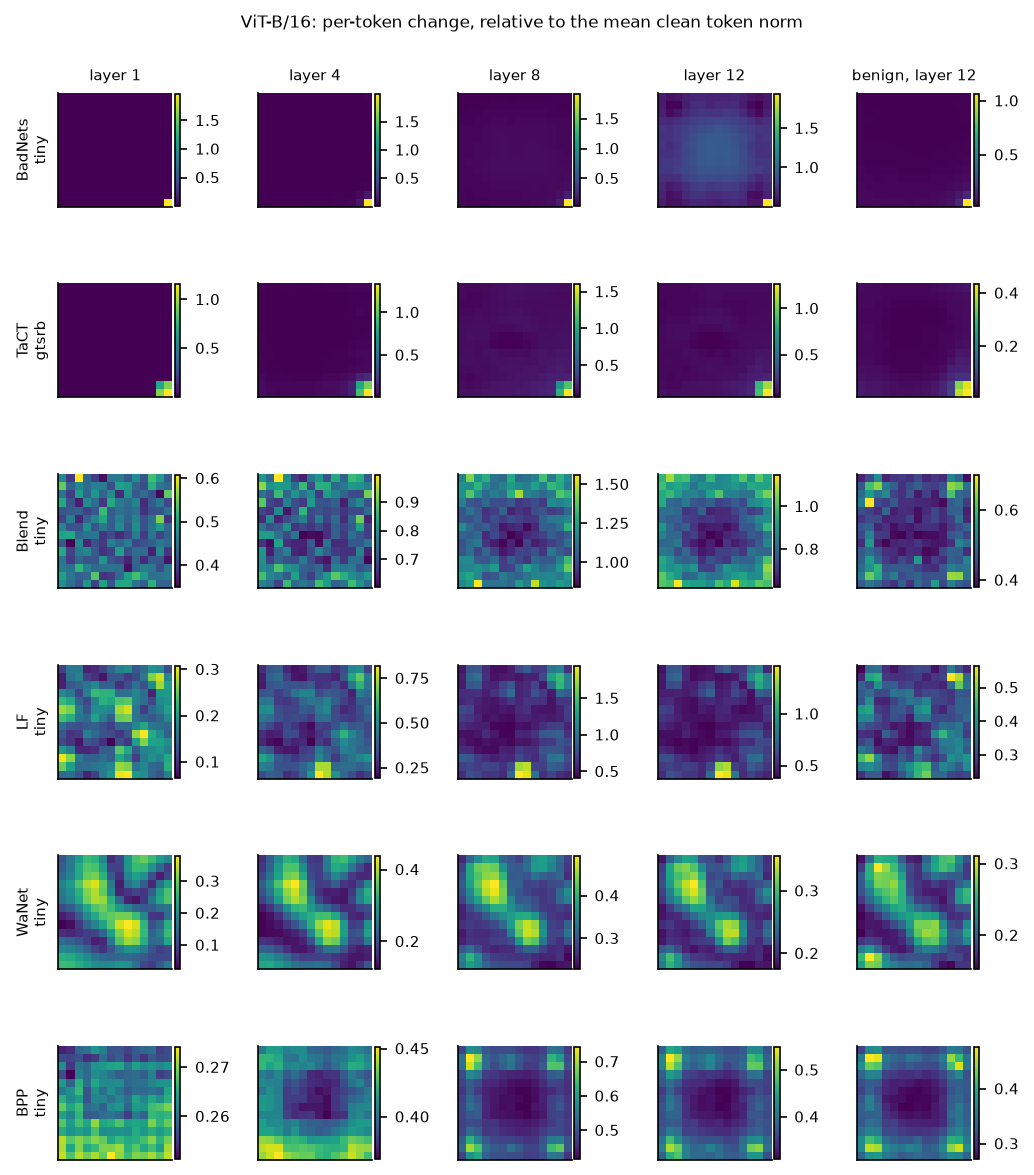

In [8]:
def token_map(record, layer):
    entry = record["token_maps"][str(layer)]
    grid = np.asarray(entry["map"]).reshape(entry["grid"])
    return grid


def show_token_maps(architecture, layers):
    attacks = [attack for attack in ATTACKS if featured_run(architecture, attack)]
    figure, axes = plt.subplots(len(attacks), len(layers) + 1, figsize=(7.0, 1.35 * len(attacks)))
    for row, attack in enumerate(attacks):
        name = featured_run(architecture, attack)
        record = load_run(name)
        control = load_run(control_name(name))
        maps = [token_map(record, layer) for layer in layers] + [token_map(control, layers[-1])]
        for column, grid in enumerate(maps):
            axis = axes[row, column]
            shown = axis.imshow(grid, cmap="viridis")
            figure.colorbar(shown, ax=axis, fraction=0.046, pad=0.02)
            axis.set_xticks([])
            axis.set_yticks([])
            axis.grid(False)
            if row == 0:
                title = f"layer {layers[column]}" if column < len(layers) else f"benign, layer {layers[-1]}"
                axis.set_title(title, fontsize=7)
        axes[row, 0].set_ylabel(f"{ATTACK_LABEL[attack]}\n{record['run']['dataset']}", fontsize=7)
    figure.suptitle(f"{ARCHITECTURE_LABEL[architecture]}: per-token change, relative to the mean clean token norm", fontsize=8)
    figure.tight_layout()
    plt.show()


show_token_maps("vit", [1, 4, 8, 12])

For a patch trigger the change starts in the trigger's tokens after block 1 and spreads across the grid in later blocks, as attention mixes the trigger's content into other tokens. For a global trigger it is spread from the start. In the benign control the last-layer map is much flatter, since a model that never learned the trigger has no reason to propagate it.

Swin-S repeats the measurement on its own grids. The panels are the last block of stage 1 (block 2, 56 by 56), stage 2 (block 4, 28 by 28), stage 3 (block 22, 14 by 14) and stage 4 (block 24, 7 by 7), with the benign control at block 24. Swin attends inside 7 by 7 windows that shift every other block, so a corner trigger can only spread 1 window per block pair, and patch merging between stages halves the grid.

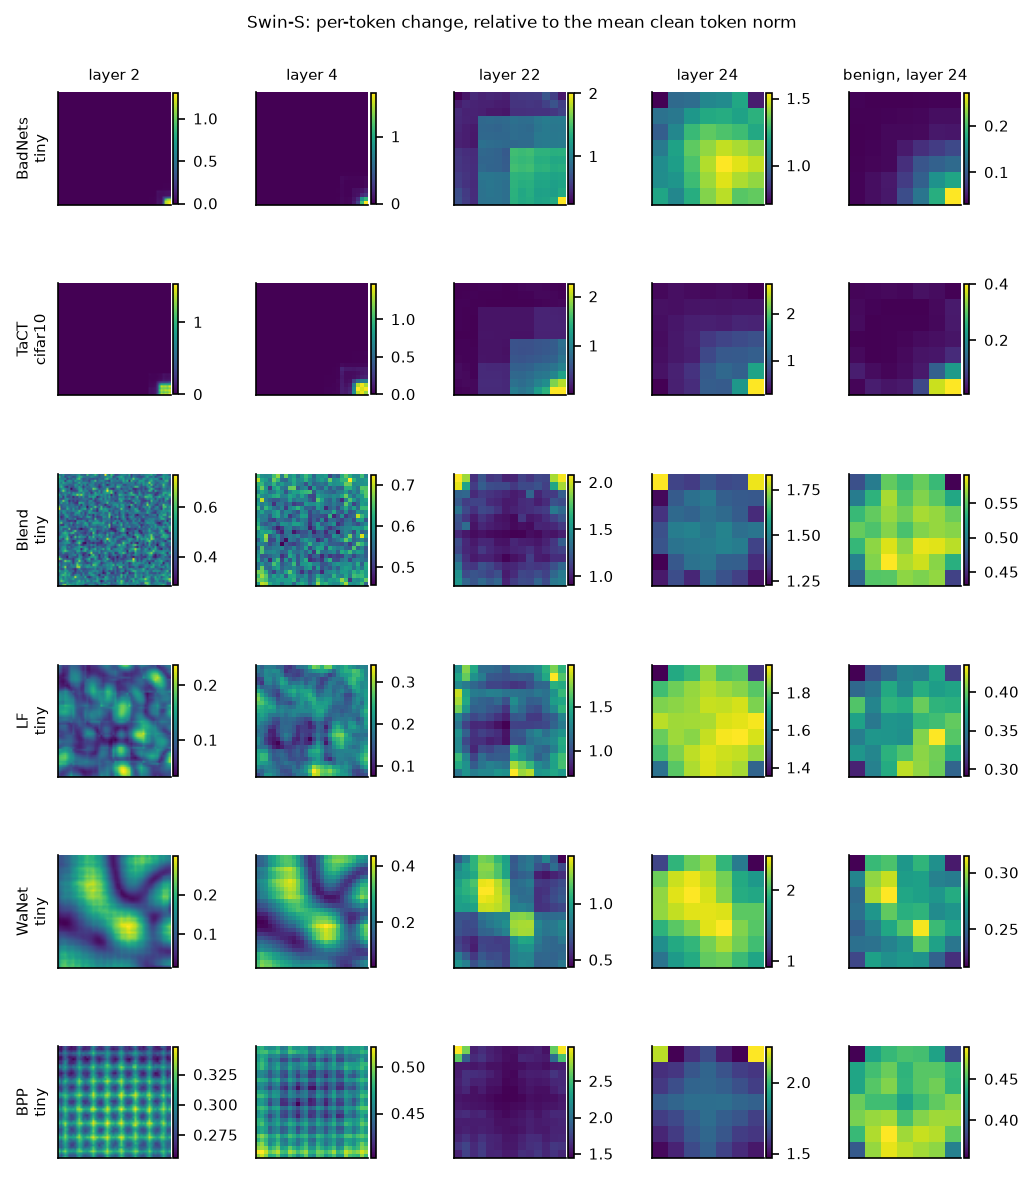

In [9]:
show_token_maps("swin", [2, 4, 22, 24])

The class token is where ViT's prediction is read, so its change is reported apart from the grid. The table gives the class token's relative change at blocks 4, 8 and 12 beside the mean and the largest change over the 196 patch tokens, for the same featured ViT runs. A class token whose change overtakes the patch mean has gathered the trigger from the patches.

In [10]:
cls_rows = []
for attack in ATTACKS:
    name = featured_run("vit", attack)
    if name is None:
        continue
    record = load_run(name)
    for layer in (4, 8, 12):
        entry = record["token_maps"][str(layer)]
        cls_rows.append(
            {
                "attack": ATTACK_LABEL[attack],
                "run": name,
                "layer": layer,
                "class token": entry["class_token"],
                "patch mean": float(np.mean(entry["map"])),
                "patch max": float(np.max(entry["map"])),
            }
        )
pd.DataFrame(cls_rows).pivot_table(index=["attack", "run"], columns="layer", values=["class token", "patch mean", "patch max"]).round(3)

class token               patch max         \
layer                                     4      8      12        4      8    
attack  run                                                                   
BPP     vit_tiny_bpp_0_05              0.122  0.636  0.844     0.451  0.743   
BadNets vit_tiny_badnet_a2o_0_05       0.010  0.106  0.681     1.998  1.919   
Blend   vit_tiny_blend_0_05            0.252  0.654  0.818     0.996  1.561   
LF      vit_tiny_lf_0_05               0.067  0.278  0.862     0.821  1.947   
TaCT    vit_gtsrb_tact_0_05            0.020  0.038  0.818     1.329  1.600   
WaNet   vit_tiny_wanet_0_05            0.092  0.553  0.601     0.437  0.492   

                                        patch mean                
layer                                12         4      8      12  
attack  run                                                       
BPP     vit_tiny_bpp_0_05         0.550      0.405  0.493  0.378  
BadNets vit_tiny_badnet_a2o_0_05  1.941      0.023  0.084  0.742  
Blend   vit_tiny_blend_0_05       1.148      0.738  1.094  0.827  
LF      vit_tiny_lf_0_05          1.467      0.369  0.677  0.548  
TaCT    vit_gtsrb_tact_0_05       1.261      0.046  0.157  0.104  
WaNet   vit_tiny_wanet_0_05       0.355      0.236  0.323  0.235

In [11]:
class_rows = []
for name in usable(ROWS)[usable(ROWS)["architecture"] == "vit"]["name"]:
    record = load_run(name)
    entry = record["token_maps"]["12"]
    control = load_run(control_name(name))["token_maps"]["12"]
    class_rows.append(
        {
            "run": name,
            "patch": record["run"]["category"] == "patch",
            "class over patch mean": entry["class_token"] / np.mean(entry["map"]),
            "class token": entry["class_token"],
            "benign class token": control["class_token"],
        }
    )
class_frame = pd.DataFrame(class_rows)
ratio = class_frame["class token"] / class_frame["benign class token"]
display(
    Markdown(
        f"Over all {len(class_frame)} usable ViT runs, the class token's relative change after block 12 is "
        f"{ratio.median():.1f} times the benign control's (median, range {ratio.min():.1f} to {ratio.max():.1f}). "
        f"Relative to the mean patch token it is {class_frame['class over patch mean'].median():.1f} times larger. "
        "The trigger's change is therefore concentrated in the token the head reads, which is what a learned backdoor "
        "needs and a benign model does not do."
    )
)
assert (ratio > 1).all()

Over all 21 usable ViT runs, the class token's relative change after block 12 is 5.7 times the benign control's (median, range 1.8 to 115.5). Relative to the mean patch token it is 1.4 times larger. The trigger's change is therefore concentrated in the token the head reads, which is what a learned backdoor needs and a benign model does not do.

The token maps above sum over all 768 coordinates of a token. `visualization.cheap_tools.run_token_maps` draws a finer statistic that the next figures reuse: for 1 image, the value on the patch grid of the 4 coordinates with the largest TAC at a layer, clean in the top row and triggered in the bottom row. Here the 4 coordinates are ranked on the fit half and the image is the first image of the eval half (`top_dimension_token_maps`). Color is the coordinate's raw value, red positive and blue negative, on a symmetric scale per coordinate.

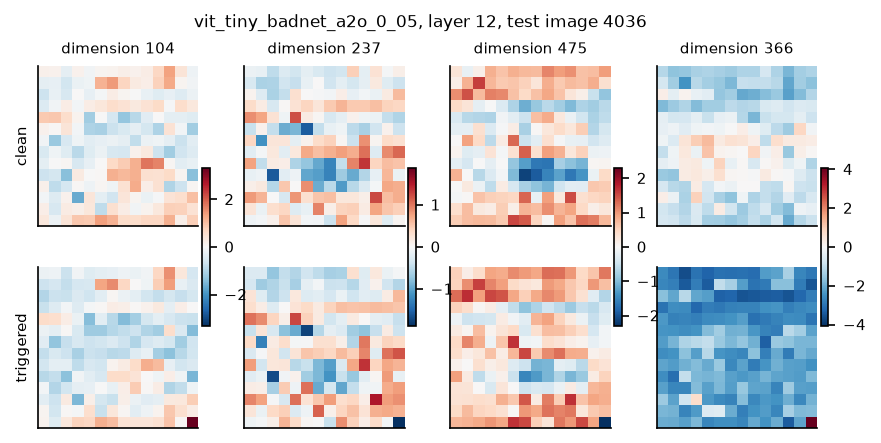

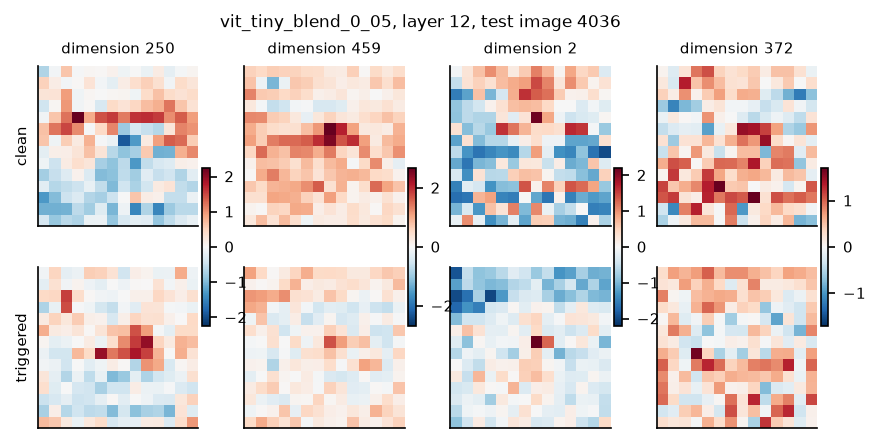

In [12]:
def show_top_dimension_maps(name, layer):
    entry = load_run(name)["top_dimension_maps"][str(layer)]
    clean, triggered = np.asarray(entry["clean"]), np.asarray(entry["triggered"])
    count = clean.shape[0]
    figure, axes = plt.subplots(2, count, figsize=(1.7 * count, 3.2))
    for column in range(count):
        limit = max(np.abs(clean[column]).max(), np.abs(triggered[column]).max())
        for row, (maps, label) in enumerate(((clean, "clean"), (triggered, "triggered"))):
            axis = axes[row, column]
            shown = axis.imshow(maps[column], cmap="RdBu_r", vmin=-limit, vmax=limit)
            axis.set_xticks([])
            axis.set_yticks([])
            axis.grid(False)
            if row == 0:
                axis.set_title(f"dimension {entry['dimensions'][column]}", fontsize=7)
            if column == 0:
                axis.set_ylabel(label, fontsize=7)
        figure.colorbar(shown, ax=axes[:, column], fraction=0.046, pad=0.02)
    figure.suptitle(f"{name}, layer {layer}, test image {entry['test_index']}", fontsize=8)
    plt.show()


show_top_dimension_maps(featured_run("vit", "badnet_a2o"), 12)
show_top_dimension_maps(featured_run("vit", "blend"), 12)

The figure shows 1 image per model and is an illustration, not a measurement: where a top coordinate changes on this image need not hold on others. What the figure does not settle is whether these coordinates matter to the prediction. A coordinate can move a lot and be ignored by the head, which is step 4's question.

Attention is how the class token reads patches. The readout recomputes each ViT block's attention weights from the block's LayerNorm output, since torchvision computes them without returning them (`class_token_attention_hook`), and keeps the class token's row. The **trigger tokens** are the patch tokens whose patch-grid input change is at least 0.25 of the largest one (`TRIGGER_TOKEN_SHARE`), which picks 1 to 4 corner tokens for a patch trigger. The mass on trigger tokens in block l, head h is

$$M_{l,h} = \frac{1}{N}\sum_{i=1}^{N}\sum_{t \in S} a_{l,h}(x_i)_{0,t}$$

| symbol | meaning |
| --- | --- |
| $a_{l,h}(x)_{0,t}$ | attention weight from the class token (query 0) to token t in block l, head h, on image x |
| $S$ | the trigger tokens |
| uniform mass | $\lvert S \rvert / 197$, what attention spread evenly would give |

The figures plot $M_{l,h}$ averaged over the 12 heads against the block, for the triggered images (orange), the same images clean (blue), the benign model on the triggered images (black dashes) and uniform attention (grey dots). Only patch triggers are drawn, because for a global trigger S covers most of the grid and the mass is near 1 by construction. Swin has no class token and its attention stays inside windows, so this readout is ViT only.

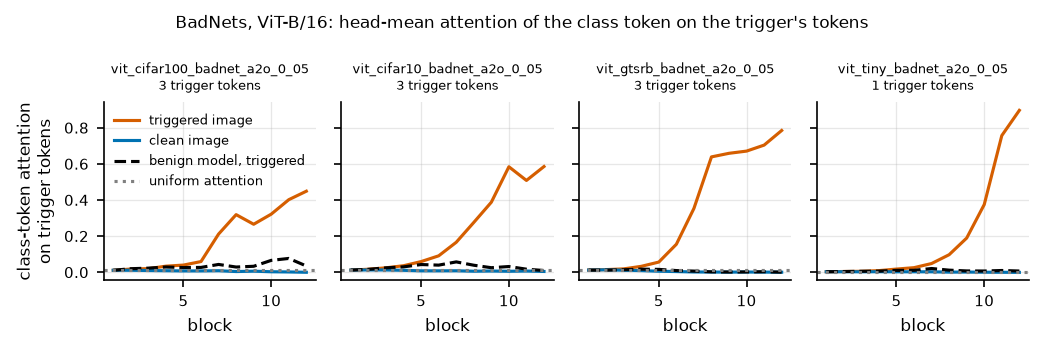

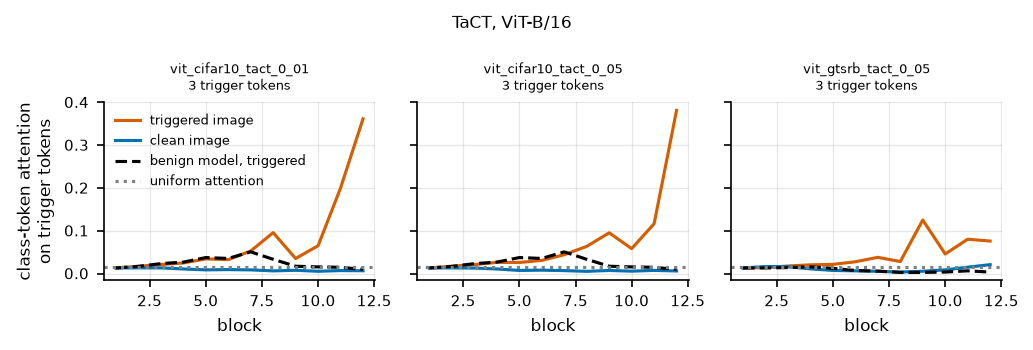

In [13]:
def show_trigger_attention(names, title):
    figure, axes = plt.subplots(1, len(names), figsize=(7.0, 2.3), sharey=True)
    for axis, name in zip(np.atleast_1d(axes), names):
        record = load_run(name)
        attention = record["attention"]
        blocks = np.arange(1, record["num_blocks"] + 1)
        axis.plot(blocks, np.asarray(attention["triggered_mass"]).mean(axis=1), label="triggered image", color=PALETTE[4])
        axis.plot(blocks, np.asarray(attention["clean_mass"]).mean(axis=1), label="clean image", color=PALETTE[0])
        control = load_run(control_name(name))
        axis.plot(blocks, np.asarray(control["attention"]["triggered_mass"]).mean(axis=1), label="benign model, triggered", color="black", linestyle="--")
        axis.axhline(attention["uniform_mass"], color="grey", linestyle=":", label="uniform attention")
        axis.set_title(f"{name}\n{attention['n_trigger_tokens']} trigger tokens", fontsize=6)
        axis.set_xlabel("block")
    np.atleast_1d(axes)[0].set_ylabel("class-token attention\non trigger tokens")
    np.atleast_1d(axes)[0].legend(fontsize=6)
    figure.suptitle(title, fontsize=8)
    figure.tight_layout()
    plt.show()


show_trigger_attention(backdoored_runs("vit", "badnet_a2o"), "BadNets, ViT-B/16: head-mean attention of the class token on the trigger's tokens")
show_trigger_attention(backdoored_runs("vit", "tact"), "TaCT, ViT-B/16")

The heatmap splits the same quantity by head for the featured BadNets model. Each cell is $\log_2$ of triggered over clean mass on the trigger tokens, red where a head looks at the corner more when the trigger is there. The 2 grids on the right are the class token's head-mean attention over the 14 by 14 patch grid in the last block, clean and triggered, on a shared scale.

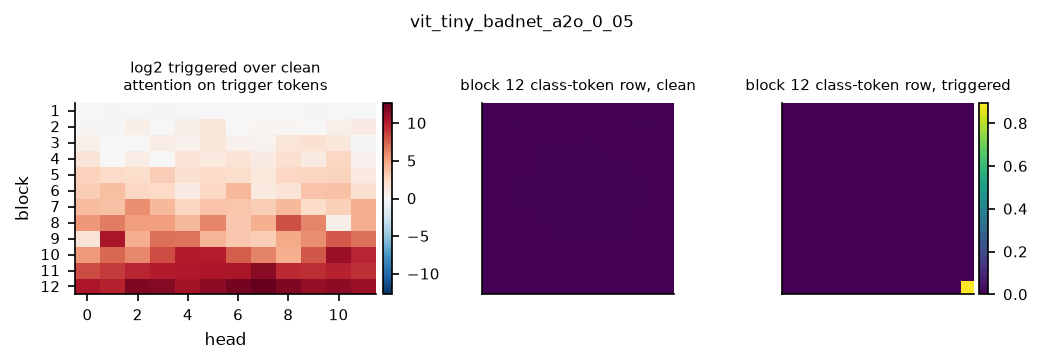

In [14]:
def show_head_ratio(name):
    record = load_run(name)
    attention = record["attention"]
    triggered = np.asarray(attention["triggered_mass"])  # (blocks, heads)
    clean = np.asarray(attention["clean_mass"])  # (blocks, heads)
    ratio = np.log2(np.maximum(triggered, 1e-6) / np.maximum(clean, 1e-6))
    triggered_row = np.asarray(attention["triggered_row"])[-1].reshape(14, 14)
    clean_row = np.asarray(attention["clean_row"])[-1].reshape(14, 14)

    figure, axes = plt.subplots(1, 3, figsize=(7.0, 2.4), gridspec_kw={"width_ratios": [1.4, 1, 1]})
    limit = np.abs(ratio).max()
    shown = axes[0].imshow(ratio, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
    axes[0].set_xlabel("head")
    axes[0].set_ylabel("block")
    axes[0].set_yticks(range(ratio.shape[0]), range(1, ratio.shape[0] + 1))
    axes[0].set_title("log2 triggered over clean\nattention on trigger tokens", fontsize=7)
    axes[0].grid(False)
    figure.colorbar(shown, ax=axes[0], fraction=0.046, pad=0.02)
    upper = max(triggered_row.max(), clean_row.max())
    for axis, grid, label in ((axes[1], clean_row, "clean"), (axes[2], triggered_row, "triggered")):
        shown = axis.imshow(grid, cmap="viridis", vmin=0, vmax=upper)
        axis.set_title(f"block {record['num_blocks']} class-token row, {label}", fontsize=7)
        axis.set_xticks([])
        axis.set_yticks([])
        axis.grid(False)
    figure.colorbar(shown, ax=axes[2], fraction=0.046, pad=0.02)
    figure.suptitle(name, fontsize=8)
    figure.tight_layout()
    plt.show()


show_head_ratio(featured_run("vit", "badnet_a2o"))

The table gives, for every usable ViT run, the head-mean mass on trigger tokens averaged over blocks 9 to 12, clean and triggered, the benign model's mass on the same triggered images and the ratio of triggered to clean. For global triggers the trigger set covers most tokens, so the ratio is near 1 whatever the model does and the row says nothing about routing.

In [15]:
attention_rows = []
for name in usable(ROWS)[usable(ROWS)["architecture"] == "vit"]["name"]:
    record = load_run(name)
    attention = record["attention"]
    control = load_run(control_name(name))["attention"]
    last = slice(-4, None)
    attention_rows.append(
        {
            "run": name,
            "attack": ATTACK_LABEL[record["run"]["attack"]],
            "trigger tokens": attention["n_trigger_tokens"],
            "uniform": attention["uniform_mass"],
            "clean, blocks 9 to 12": float(np.asarray(attention["clean_mass"])[last].mean()),
            "triggered, blocks 9 to 12": float(np.asarray(attention["triggered_mass"])[last].mean()),
            "benign triggered, blocks 9 to 12": float(np.asarray(control["triggered_mass"])[last].mean()),
        }
    )
attention_frame = pd.DataFrame(attention_rows).set_index("run")
attention_frame["triggered over clean"] = attention_frame["triggered, blocks 9 to 12"] / attention_frame["clean, blocks 9 to 12"]
attention_frame.sort_values(["attack", "run"]).round(3)

,attack,trigger tokens,uniform,"clean, blocks 9 to 12","triggered, blocks 9 to 12","benign triggered, blocks 9 to 12",triggered over clean
run,,,,,,,
vit_cifar100_bpp_0_05,BPP,196,0.995,0.713,0.930,0.663,1.305
vit_cifar10_bpp_0_05,BPP,196,0.995,0.942,0.977,0.908,1.038
vit_gtsrb_bpp_0_05,BPP,196,0.995,0.870,0.988,0.709,1.135
vit_tiny_bpp_0_05,BPP,196,0.995,0.709,0.923,0.749,1.302
vit_cifar100_badnet_a2o_0_05,BadNets,3,0.015,0.004,0.361,0.054,96.795
vit_cifar10_badnet_a2o_0_05,BadNets,3,0.015,0.007,0.518,0.022,73.826
vit_gtsrb_badnet_a2o_0_05,BadNets,3,0.015,0.002,0.706,0.003,366.267
vit_tiny_badnet_a2o_0_05,BadNets,1,0.005,0.001,0.556,0.009,449.703
vit_cifar100_blend_0_05,Blend,196,0.995,0.661,0.976,0.644,1.477


In [16]:
patch_frame = attention_frame[attention_frame["attack"].isin(["BadNets", "TaCT"])].copy()
patch_frame["benign over clean"] = patch_frame["benign triggered, blocks 9 to 12"] / patch_frame["clean, blocks 9 to 12"]
global_frame = attention_frame[~attention_frame["attack"].isin(["BadNets", "TaCT"])]
by_attack = patch_frame.groupby("attack")[["triggered over clean", "benign over clean"]].agg(["min", "max"])
display(
    Markdown(
        f"On the {len(patch_frame)} patch-trigger ViT runs the trigger covers {patch_frame['trigger tokens'].min()} to "
        f"{patch_frame['trigger tokens'].max()} tokens. In blocks 9 to 12 the class token's head-mean attention on them grows, from the clean "
        f"to the triggered image, by a factor of {by_attack.loc['BadNets', ('triggered over clean', 'min')]:.0f} to "
        f"{by_attack.loc['BadNets', ('triggered over clean', 'max')]:.0f} on BadNets, against {by_attack.loc['BadNets', ('benign over clean', 'min')]:.1f} to "
        f"{by_attack.loc['BadNets', ('benign over clean', 'max')]:.1f} for the benign model shown the same trigger, so the backdoored class token has learned to read the corner. "
        f"On TaCT the factor is {by_attack.loc['TaCT', ('triggered over clean', 'min')]:.0f} to {by_attack.loc['TaCT', ('triggered over clean', 'max')]:.0f} "
        f"against {by_attack.loc['TaCT', ('benign over clean', 'min')]:.1f} to {by_attack.loc['TaCT', ('benign over clean', 'max')]:.1f} for its controls, "
        "a smaller factor than BadNets and still above every TaCT control. "
        f"For the {len(global_frame)} global-trigger runs the trigger set covers most of the grid and the factor "
        f"({global_frame['triggered over clean'].min():.2f} to {global_frame['triggered over clean'].max():.2f}) says nothing about routing."
    )
)
for attack in ("BadNets", "TaCT"):
    subset = patch_frame[patch_frame["attack"] == attack]
    assert (subset["triggered over clean"] > subset["benign over clean"].max()).all()

On the 7 patch-trigger ViT runs the trigger covers 1 to 3 tokens. In blocks 9 to 12 the class token's head-mean attention on them grows, from the clean to the triggered image, by a factor of 74 to 450 on BadNets, against 1.5 to 14.4 for the benign model shown the same trigger, so the backdoored class token has learned to read the corner. On TaCT the factor is 7 to 24 against 0.3 to 2.1 for its controls, a smaller factor than BadNets and still above every TaCT control. For the 14 global-trigger runs the trigger set covers most of the grid and the factor (1.02 to 1.48) says nothing about routing.

## Step 3, how the backdoor grows with depth

Step 2 showed where the change sits. This step asks when the representation the head will read, the pooled feature, separates triggered images from clean ones. 3 quantities are computed at every layer by `layer_row` on all pairs of a run, as descriptive statistics that score nothing.

| quantity | formula | reading |
| --- | --- | --- |
| relative direction norm | $\lVert r_l \rVert \,/\, \frac{1}{N}\sum_i \lVert \bar h_l(x_i) \rVert$ with $r_l = \frac{1}{N}\sum_i \big(\bar h_l(\tilde x_i) - \bar h_l(x_i)\big)$ | how far the mean triggered feature sits from the mean clean feature, in units of the clean feature norm |
| normalized max TAC | $\max_k \mathrm{TAC}_{l,k} \,/\, \frac{1}{N D}\sum_{i,k} \lvert \bar h_l(x_i)_k \rvert$ with $\mathrm{TAC}_{l,k} = \frac{1}{N}\sum_i \lvert \bar h_l(\tilde x_i)_k - \bar h_l(x_i)_k \rvert$ | the largest single-coordinate change against a typical clean activation |
| CKA | debiased linear CKA between the clean and the triggered feature sets (`analysis.cka.debiased_linear_cka`) | 1 when the 2 sets are the same representation up to rotation and scale, lower when the trigger reorganizes it |

Here $\bar h_l$ is the pooled feature, D its width and N the number of pairs. The figure has 3 panels per architecture, 1 per quantity. Each colored line is 1 attack averaged over the datasets it has usable models on (the count is in the legend), and the black dashed line is the mean over all the benign controls of those models. The relative direction norm is drawn on a log scale because it spans 2 orders of magnitude.

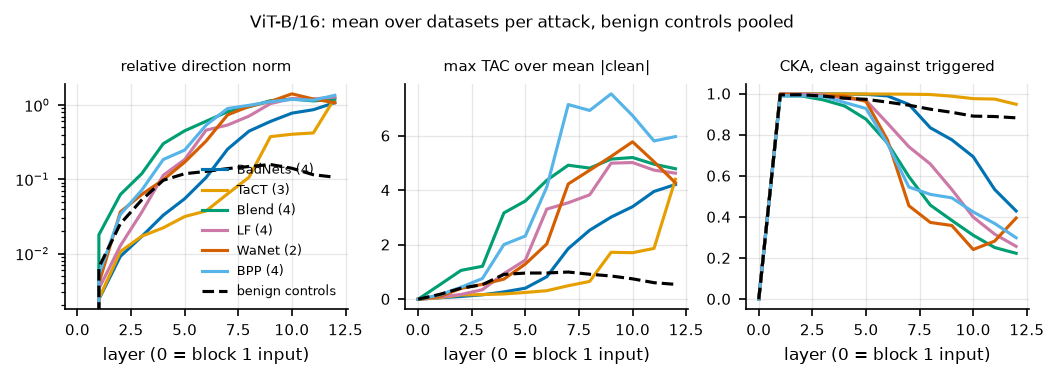

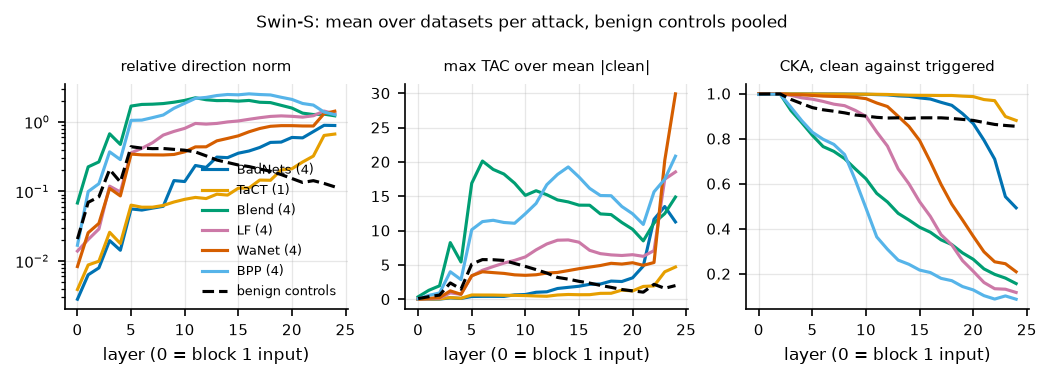

In [17]:
METRICS = {
    "rel_direction_norm": "relative direction norm",
    "normalized_max_tac": "max TAC over mean |clean|",
    "cka": "CKA, clean against triggered",
}


def layer_values(record, metric):
    layers = record["layers"]
    if metric == "normalized_max_tac":
        values = np.asarray([row["max_tac"] / max(row["mean_abs_clean"], 1e-8) for row in layers])
        return values
    values = np.asarray([row[metric] for row in layers])
    return values


def show_depth_curves(architecture):
    figure, axes = plt.subplots(1, len(METRICS), figsize=(7.0, 2.5))
    for axis, (metric, label) in zip(axes, METRICS.items()):
        control_curves = []
        for attack in ATTACKS:
            names = backdoored_runs(architecture, attack)
            if not names:
                continue
            curves = []
            for name in names:
                record = load_run(name)
                depth = np.arange(record["num_blocks"] + 1)
                curves.append(layer_values(record, metric))
                control_curves.append(layer_values(load_run(control_name(name)), metric))
            axis.plot(depth, np.mean(curves, axis=0), color=ATTACK_COLOUR[attack], label=f"{ATTACK_LABEL[attack]} ({len(names)})")
        axis.plot(depth, np.mean(control_curves, axis=0), color="black", linestyle="--", label="benign controls")
        axis.set_xlabel("layer (0 = block 1 input)")
        axis.set_title(label, fontsize=7)
        if metric == "rel_direction_norm":
            axis.set_yscale("log")
    axes[0].legend(fontsize=6)
    figure.suptitle(f"{ARCHITECTURE_LABEL[architecture]}: mean over datasets per attack, benign controls pooled", fontsize=8)
    figure.tight_layout()
    plt.show()


show_depth_curves("vit")
show_depth_curves("swin")

The table gives, per architecture and attack, the **onset layer** (the first layer whose relative direction norm reaches half its largest value), the **peak layer** (where it is largest), the onset as a share of the depth so ViT and Swin compare, and the final-layer direction norm and CKA beside the benign control's. Swin-S has 24 blocks and ViT-B/16 12, so an onset share of 0.75 is block 9 on ViT and block 18 on Swin.

In [18]:
depth_rows = []
for _, row in usable(ROWS).iterrows():
    record = load_run(row["name"])
    control = load_run(control_name(row["name"]))
    depth_rows.append(
        {
            "run": row["name"],
            "architecture": row["architecture"],
            "attack": ATTACK_LABEL[row["attack"]],
            "onset layer": record["onset_layer"],
            "peak layer": record["peak_layer"],
            "onset depth share": record["onset_layer"] / record["num_blocks"],
            "final rel. direction": row["final_rel_direction_norm"],
            "benign final rel. direction": control["layers"][-1]["rel_direction_norm"],
            "final CKA": row["final_cka"],
            "benign final CKA": control["layers"][-1]["cka"],
        }
    )
depth_frame = pd.DataFrame(depth_rows).set_index("run")
depth_frame.groupby(["architecture", "attack"]).agg(
    onset_min=("onset layer", "min"),
    onset_median=("onset layer", "median"),
    onset_max=("onset layer", "max"),
    models=("onset layer", "count"),
    onset_share=("onset depth share", "mean"),
    final_direction=("final rel. direction", "mean"),
    benign_final_direction=("benign final rel. direction", "mean"),
    final_cka=("final CKA", "mean"),
    benign_final_cka=("benign final CKA", "mean"),
).round(3)

onset_min  onset_median  onset_max  models  onset_share  \
architecture attack                                                             
swin         BPP              5           9.0         10       4        0.344   
             BadNets         13          18.0         23       4        0.750   
             Blend            5           5.0          5       4        0.208   
             LF               8           9.0         17       4        0.448   
             TaCT            23          23.0         23       1        0.958   
             WaNet           15          16.0         23       4        0.729   
vit          BPP              6           7.5          9       4        0.625   
             BadNets          8           9.5         10       4        0.771   
             Blend            5           6.5          8       4        0.542   
             LF               6           9.0          9       4        0.688   
             TaCT             9          12.0         12       3        0.917   
             WaNet            7           7.0          7       2        0.583   

                      final_direction  benign_final_direction  final_cka  \
architecture attack                                                        
swin         BPP                1.269                   0.170      0.088   
             BadNets            0.885                   0.019      0.494   
             Blend              1.220                   0.268      0.158   
             LF                 1.306                   0.113      0.118   
             TaCT               0.667                   0.009      0.882   
             WaNet              1.423                   0.039      0.210   
vit          BPP                1.350                   0.126      0.299   
             BadNets            1.075                   0.040      0.430   
             Blend              1.196                   0.237      0.223   
             LF                 1.278                   0.114      0.257   
             TaCT               1.239                   0.025      0.949   
             WaNet              1.074                   0.047      0.395   

                      benign_final_cka  
architecture attack                     
swin         BPP                 0.755  
             BadNets             0.998  
             Blend               0.606  
             LF                  0.909  
             TaCT                0.990  
             WaNet               0.979  
vit          BPP                 0.838  
             BadNets             0.997  
             Blend               0.657  
             LF                  0.908  
             TaCT                0.998  
             WaNet               0.977

In [19]:
onset = depth_frame.groupby(["architecture", "attack"])["onset depth share"].mean()
final_ratio = depth_frame["final rel. direction"] / depth_frame["benign final rel. direction"]
display(
    Markdown(
        "Every backdoored curve rises above its benign control. The controls peak in the middle of the network and fall, "
        "so the depth profile belongs to the learned backdoor rather than to the input change. "
        f"At the last layer the relative direction norm is {final_ratio.median():.1f} times the benign control's (median over "
        f"{len(depth_frame)} runs, range {final_ratio.min():.1f} to {final_ratio.max():.1f}). CKA between clean and triggered features "
        f"falls to a median {depth_frame['final CKA'].median():.3f} against {depth_frame['benign final CKA'].median():.3f} for the controls. "
        f"On ViT the onset falls between {onset['vit'].min():.2f} and {onset['vit'].max():.2f} of the depth "
        f"({', '.join(f'{attack} {value:.2f}' for attack, value in onset['vit'].items())}), "
        f"on Swin between {onset['swin'].min():.2f} and {onset['swin'].max():.2f} "
        f"({', '.join(f'{attack} {value:.2f}' for attack, value in onset['swin'].items())})."
    )
)
assert (final_ratio > 1).all()

Every backdoored curve rises above its benign control. The controls peak in the middle of the network and fall, so the depth profile belongs to the learned backdoor rather than to the input change. At the last layer the relative direction norm is 15.9 times the benign control's (median over 42 runs, range 2.3 to 188.7). CKA between clean and triggered features falls to a median 0.241 against 0.939 for the controls. On ViT the onset falls between 0.54 and 0.92 of the depth (BPP 0.62, BadNets 0.77, Blend 0.54, LF 0.69, TaCT 0.92, WaNet 0.58), on Swin between 0.21 and 0.96 (BPP 0.34, BadNets 0.75, Blend 0.21, LF 0.45, TaCT 0.96, WaNet 0.73).

## Step 4, backdoor neurons against a backdoor direction

The literature on backdoor neurons ranks coordinates by TAC and prunes the top ones (Zheng et al., ECCV 2022, on ConvNet channels). If the backdoor in a transformer lived in a few coordinates, 3 things would hold. The top coordinates would be the same across images and stable across halves of the data. They would separate clean from triggered images as well as anything else. Deleting them would remove the backdoor while deleting random coordinates would not. This step tests each, and tests the same 3 things for the backdoor direction, which is 1 unit vector in the same space, a "rotated neuron".

The heatmap shows, for 3 featured ViT runs, TAC at every layer for the 20 coordinates with the largest TAC at the last layer, divided by the layer's mean absolute clean activation. Rows are layers, columns are coordinate indices.

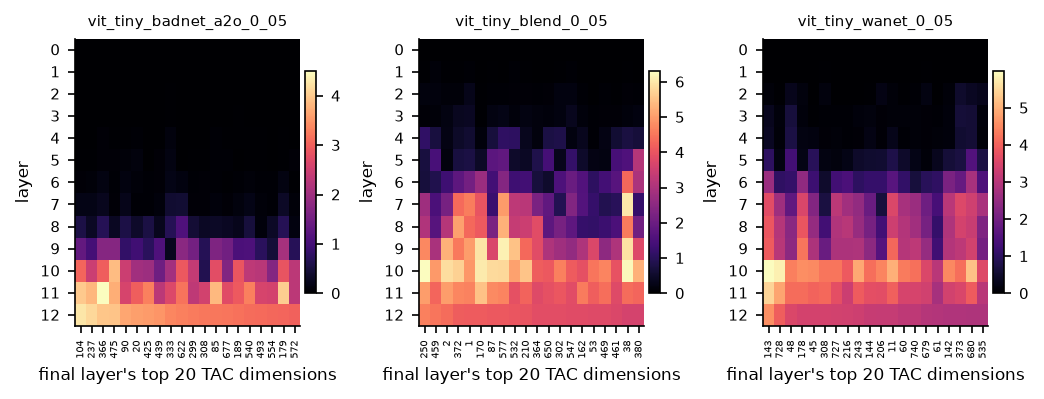

In [20]:
def show_tac_heatmap(names):
    figure, axes = plt.subplots(1, len(names), figsize=(7.0, 2.7))
    for axis, name in zip(np.atleast_1d(axes), names):
        record = load_run(name)
        rows = [row for row in record["layers"] if row["tac_of_final_top"] is not None]
        matrix = np.asarray([np.asarray(row["tac_of_final_top"]) / max(row["mean_abs_clean"], 1e-8) for row in rows])
        shown = axis.imshow(matrix, aspect="auto", cmap="magma")
        axis.set_yticks(range(len(rows)), [row["layer"] for row in rows])
        axis.set_xticks(range(TOP_DIMENSIONS), record["layers"][-1]["top_tac_dimensions"], rotation=90, fontsize=5)
        axis.set_xlabel("final layer's top 20 TAC dimensions")
        axis.set_ylabel("layer")
        axis.set_title(name, fontsize=7)
        axis.grid(False)
        figure.colorbar(shown, ax=axis, fraction=0.046, pad=0.02)
    figure.tight_layout()
    plt.show()


show_tac_heatmap([featured_run("vit", attack) for attack in ("badnet_a2o", "blend", "wanet")])

The final top coordinates carry almost nothing until the last few blocks. That they are late readout coordinates rather than units that carry the trigger through the network is a hypothesis this figure suggests and does not test, since nothing here removes them at an earlier layer.

The next figure asks whether the same coordinates recur across attacks on 1 model family (1 architecture on 1 dataset). All models of a family are fine-tuned from the same ImageNet weights, so a coordinate index names the same unit at initialization, which is the only reason a shared index can mean anything. Each cell is the Jaccard index, $\lvert A \cap B \rvert / \lvert A \cup B \rvert$, of the final-layer top-20 TAC sets of 2 runs, backdoored runs and benign controls together. 2 references frame it. **Chance** is the expected Jaccard of 2 independent random 20-of-768 draws, computed exactly by `chance_jaccard`. The **split-half ceiling** is the Jaccard between the top-20 sets ranked on the fit half and on the eval half of the same run, which is what a perfectly reproducible ranking would reach on 400 pairs.

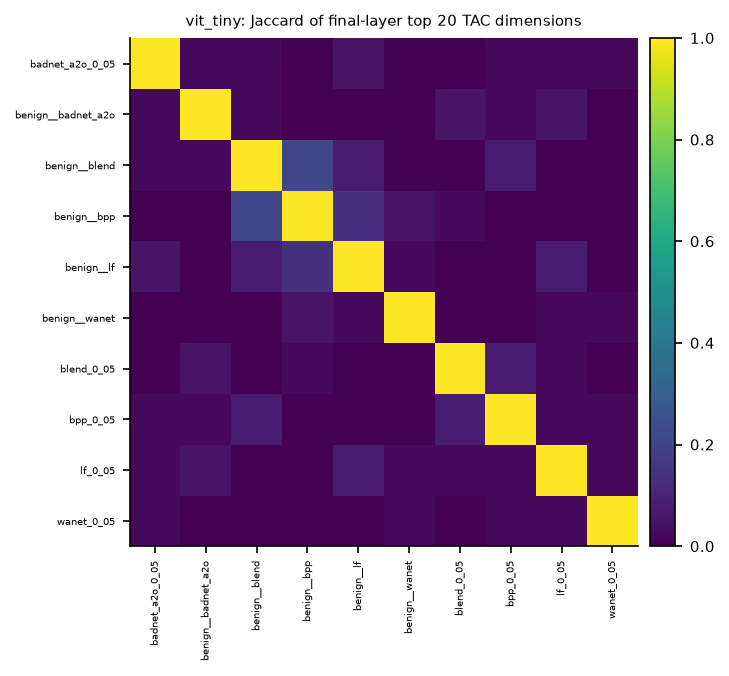

split-half ceiling, mean over backdoored runs: {'swin': 0.909, 'vit': 0.887}


,backdoored pairs,"mean Jaccard, backdoored against backdoored","max Jaccard, backdoored against backdoored","mean Jaccard, benign probes against each other",chance
family,,,,,
swin_cifar10,15,0.086,0.176,0.434,0.014
swin_cifar100,10,0.070,0.111,0.158,0.014
swin_gtsrb,10,0.103,0.176,0.133,0.014
swin_tiny,10,0.073,0.143,0.248,0.014
vit_cifar10,21,0.021,0.081,0.142,0.014
vit_cifar100,6,0.031,0.081,0.109,0.014
vit_gtsrb,10,0.010,0.053,0.076,0.014
vit_tiny,10,0.026,0.081,0.054,0.014


In [21]:
def show_overlap(family):
    entry = SUMMARY["top_dimension_overlap"][family]
    names, matrix = entry["names"], np.asarray(entry["jaccard"])
    labels = [name.replace(f"{family}_", "") for name in names]
    figure, axis = plt.subplots(figsize=(5.2, 4.4))
    shown = axis.imshow(matrix, cmap="viridis", vmin=0, vmax=1)
    axis.set_xticks(range(len(labels)), labels, rotation=90, fontsize=5)
    axis.set_yticks(range(len(labels)), labels, fontsize=5)
    axis.grid(False)
    figure.colorbar(shown, ax=axis, fraction=0.046, pad=0.02)
    axis.set_title(f"{family}: Jaccard of final-layer top {TOP_DIMENSIONS} TAC dimensions", fontsize=7)
    plt.show()


def overlap_statistics(family):
    entry = SUMMARY["top_dimension_overlap"][family]
    names, matrix = entry["names"], np.asarray(entry["jaccard"])
    benign = np.asarray(["benign" in name for name in names])
    pairs = [(i, j) for i in range(len(names)) for j in range(i + 1, len(names))]
    between_backdoors = [matrix[i, j] for i, j in pairs if not benign[i] and not benign[j]]
    between_controls = [matrix[i, j] for i, j in pairs if benign[i] and benign[j]]
    statistics = {
        "family": family,
        "backdoored pairs": len(between_backdoors),
        "mean Jaccard, backdoored against backdoored": float(np.mean(between_backdoors)) if between_backdoors else None,
        "max Jaccard, backdoored against backdoored": float(np.max(between_backdoors)) if between_backdoors else None,
        "mean Jaccard, benign probes against each other": float(np.mean(between_controls)) if between_controls else None,
        "chance": SUMMARY["chance_jaccard"],
    }
    return statistics


show_overlap("vit_tiny")
ceiling = usable(ROWS).groupby("architecture")["final_split_half_jaccard"].mean()
print("split-half ceiling, mean over backdoored runs:", ceiling.round(3).to_dict())
pd.DataFrame([overlap_statistics(family) for family in sorted(SUMMARY["top_dimension_overlap"])]).set_index("family").round(3)

In [22]:
family_statistics = pd.DataFrame([overlap_statistics(family) for family in sorted(SUMMARY["top_dimension_overlap"])])
display(
    Markdown(
        f"Between backdoored runs of the same family the mean Jaccard of the top-20 TAC sets is "
        f"{family_statistics['mean Jaccard, backdoored against backdoored'].mean():.3f} (family means from "
        f"{family_statistics['mean Jaccard, backdoored against backdoored'].min():.3f} to "
        f"{family_statistics['mean Jaccard, backdoored against backdoored'].max():.3f}), against a chance level of "
        f"{SUMMARY['chance_jaccard']:.3f} and a split-half ceiling of {ceiling['vit']:.3f} on ViT and {ceiling['swin']:.3f} on Swin. "
        "The top TAC coordinates are reproducible within a model and largely different between attacks, "
        "so a list of backdoor neurons found for 1 attack does not transfer to another. "
        "Whether the remaining overlap is made of coordinates that move for any input change is a hypothesis the benign rows of the matrix suggest and no removal here tests."
    )
)

Between backdoored runs of the same family the mean Jaccard of the top-20 TAC sets is 0.053 (family means from 0.010 to 0.103), against a chance level of 0.014 and a split-half ceiling of 0.887 on ViT and 0.909 on Swin. The top TAC coordinates are reproducible within a model and largely different between attacks, so a list of backdoor neurons found for 1 attack does not transfer to another. Whether the remaining overlap is made of coordinates that move for any input change is a hypothesis the benign rows of the matrix suggest and no removal here tests.

Separability is the next test. For 3 featured runs the histograms show, on the eval half, the activation of the 3 top-TAC coordinates at the last layer (ranked on the fit half) for clean and triggered images, and the projection of the same images onto the backdoor direction fitted on the fit half. The title gives 3 AUROCs, each the probability that a random triggered image scores above a random clean one after orienting each coordinate by the sign of its fit-half change: the top-TAC coordinate, the single coordinate with the best fit-half AUROC and the direction (`neuron_readout`).

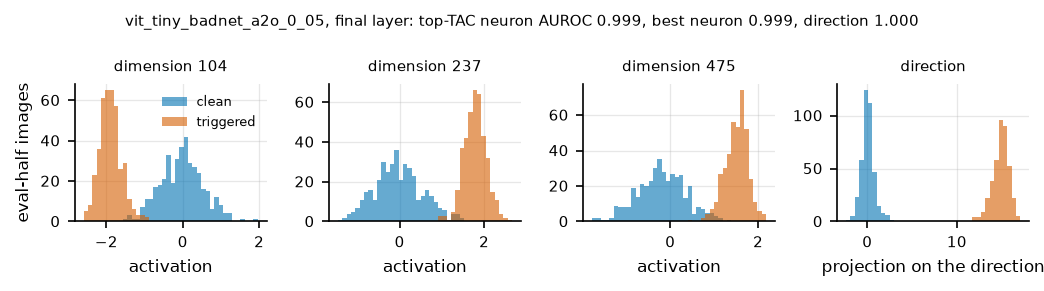

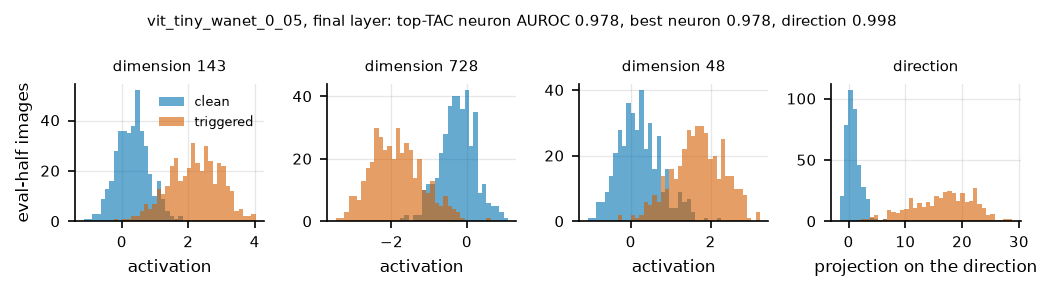

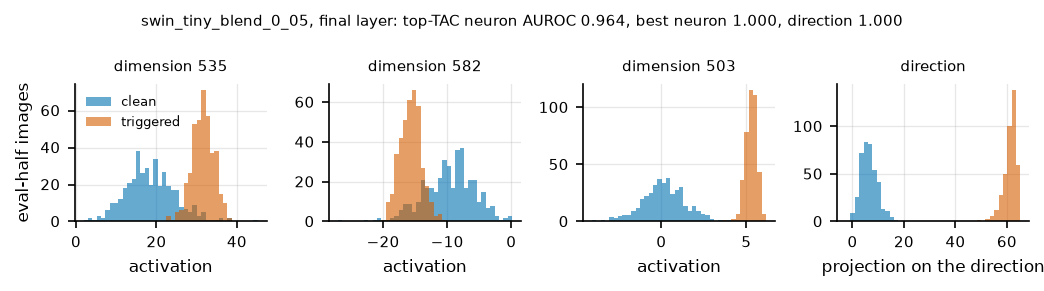

In [23]:
def show_histograms(name):
    record = load_run(name)
    histograms = record["neurons"]["histograms"]
    figure, axes = plt.subplots(1, len(histograms), figsize=(7.0, 1.9))
    for axis, (key, entry) in zip(axes, histograms.items()):
        edges = np.asarray(entry["edges"])
        centres = (edges[:-1] + edges[1:]) / 2
        width = edges[1] - edges[0]
        axis.bar(centres, entry["clean"], width=width, alpha=0.6, label="clean", color=PALETTE[0])
        axis.bar(centres, entry["triggered"], width=width, alpha=0.6, label="triggered", color=PALETTE[4])
        axis.set_title(key.replace("_", " "), fontsize=7)
        axis.set_xlabel("activation" if key != "direction" else "projection on the direction")
    axes[0].set_ylabel("eval-half images")
    axes[0].legend(fontsize=6)
    neurons = record["neurons"]
    figure.suptitle(
        f"{name}, final layer: top-TAC neuron AUROC {neurons['top_tac_eval_auroc'][0]:.3f}, "
        f"best neuron {neurons['best_fit_dimension_eval_auroc']:.3f}, direction {neurons['direction_eval_auroc']:.3f}",
        fontsize=7,
    )
    figure.tight_layout()
    plt.show()


show_histograms(featured_run("vit", "badnet_a2o"))
show_histograms(featured_run("vit", "wanet"))
show_histograms(featured_run("swin", "blend"))

The scatter repeats the comparison on every usable run. The left panel plots the direction's eval AUROC against the best single coordinate's. The right panel describes the direction's shape: its **participation ratio** $1 / \sum_k u_k^4$ for the unit direction u, which is 1 for a direction along a single coordinate and about $D/3$ (256 for 768 dimensions) for a random direction, against the share of its squared length that sits in the 20 top-TAC coordinates, $\sum_{k \in \text{top 20}} u_k^2$. The table under it averages the same numbers per attack and adds the **direction share** $\lVert r \rVert^2 / \frac{1}{N}\sum_i \lVert d_i \rVert^2$, which is 1 when every image moves by the same vector and near 0 when the per-image moves cancel.

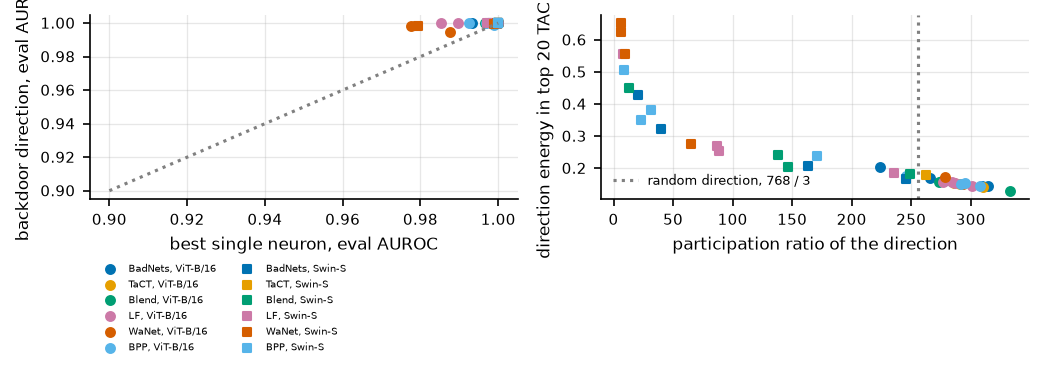

best_neuron_eval_auroc  top_tac_neuron_eval_auroc  \
architecture attack                                                          
swin         badnet_a2o                   1.000                      0.938   
             blend                        1.000                      0.986   
             bpp                          1.000                      0.999   
             lf                           0.999                      0.992   
             tact                         1.000                      0.798   
             wanet                        0.994                      0.992   
vit          badnet_a2o                   0.998                      0.990   
             blend                        0.999                      0.999   
             bpp                          0.997                      0.997   
             lf                           0.994                      0.995   
             tact                         1.000                      1.000   
             wanet                        0.983                      0.967   

                         direction_eval_auroc  final_participation  \
architecture attack                                                  
swin         badnet_a2o                 1.000              117.668   
             blend                      1.000              136.566   
             bpp                        1.000               58.284   
             lf                         1.000              104.673   
             tact                       1.000              262.644   
             wanet                      0.999               21.705   
vit          badnet_a2o                 1.000              278.414   
             blend                      1.000              289.834   
             bpp                        1.000              285.018   
             lf                         1.000              287.163   
             tact                       1.000              295.565   
             wanet                      0.996              285.994   

                         final_top_tac_direction_energy  final_direction_share  
architecture attack                                                             
swin         badnet_a2o                           0.281                  0.601  
             blend                                0.269                  0.671  
             bpp                                  0.369                  0.720  
             lf                                   0.316                  0.736  
             tact                                 0.178                  0.981  
             wanet                                0.527                  0.759  
vit          badnet_a2o                           0.166                  0.590  
             blend                                0.152                  0.616  
             bpp                                  0.156                  0.722  
             lf                                   0.153                  0.680  
             tact                                 0.148                  0.984  
             wanet                                0.161                  0.701

In [24]:
figure, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))
for architecture, marker in (("vit", "o"), ("swin", "s")):
    rows = usable(ROWS)[usable(ROWS)["architecture"] == architecture]
    for attack in ATTACKS:
        subset = rows[rows["attack"] == attack]
        if not len(subset):
            continue
        axes[0].scatter(subset["best_neuron_eval_auroc"], subset["direction_eval_auroc"], marker=marker, color=ATTACK_COLOUR[attack], s=18, label=f"{ATTACK_LABEL[attack]}, {ARCHITECTURE_LABEL[architecture]}")
        axes[1].scatter(subset["final_participation"], subset["final_top_tac_direction_energy"], marker=marker, color=ATTACK_COLOUR[attack], s=18)
axes[0].plot([0.9, 1], [0.9, 1], color="grey", linestyle=":")
axes[0].set_xlabel("best single neuron, eval AUROC")
axes[0].set_ylabel("backdoor direction, eval AUROC")
axes[1].axvline(768 / 3, color="grey", linestyle=":", label="random direction, 768 / 3")
axes[1].set_xlabel("participation ratio of the direction")
axes[1].set_ylabel("direction energy in top 20 TAC dims")
axes[1].legend(fontsize=6)
axes[0].legend(fontsize=5, ncol=2, bbox_to_anchor=(0.0, -0.3), loc="upper left")
figure.tight_layout()
plt.show()
usable(ROWS).groupby(["architecture", "attack"])[["best_neuron_eval_auroc", "top_tac_neuron_eval_auroc", "direction_eval_auroc", "final_participation", "final_top_tac_direction_energy", "final_direction_share"]].mean().round(3)

In [25]:
separability = usable(ROWS)
gap = separability["direction_eval_auroc"] - separability["best_neuron_eval_auroc"]
display(
    Markdown(
        f"On the eval half the direction's AUROC is at least the best single neuron's on {int((gap >= -0.005).sum())} of "
        f"{len(separability)} runs (median gap {gap.median():+.3f}, smallest {gap.min():+.3f}). "
        f"The direction's participation ratio has a median of {separability['final_participation'].median():.0f} coordinates "
        f"and the 20 top-TAC coordinates carry a median {separability['final_top_tac_direction_energy'].median():.2f} of its squared length. "
        "At the last layer a single coordinate already separates clean from triggered images almost perfectly, so separability alone does not tell a neuron from a direction. "
        "The ablation below does."
    )
)

On the eval half the direction's AUROC is at least the best single neuron's on 42 of 42 runs (median gap +0.000, smallest +0.000). The direction's participation ratio has a median of 247 coordinates and the 20 top-TAC coordinates carry a median 0.18 of its squared length. At the last layer a single coordinate already separates clean from triggered images almost perfectly, so separability alone does not tell a neuron from a direction. The ablation below does.

Separability is correlational. The causal test deletes a candidate from the residual stream at the last block's output on every token and measures ASR and target-class recall on the eval half (`ablation_readout`). Removing 1 unit direction u sets every token x to $x - (x \cdot u)\,u$. Zeroing k coordinates is the same operation for k axis-aligned directions, so the comparison asks which basis the backdoor lives in (`tests/test_backdoor_manifestation.py` checks that the 2 hooks agree when u is an axis).

A removal that breaks the backdoor proves little unless a comparable removal does not. Every direction removal has 6 controls, all fitted on the fit half.

| control | what it rules out |
| --- | --- |
| isotropic random direction, 3 draws | removing any direction breaks the model |
| clean PC 1, the top principal direction of the clean features | removing the highest-variance direction breaks the model |
| variance-matched clean PC, the clean principal direction whose clean variance is closest to the backdoor direction's | the effect comes from the amount of clean energy removed |
| target-class offset, mean target-class feature minus mean clean feature | the backdoor is erased only because the target class's own evidence is erased |
| other trigger's direction on the same model (Blend for patch and warp models, BadNets for the others) | any trigger's direction would do |
| benign model's direction for the same trigger | the direction is the input change's footprint rather than a learned backdoor |

The bars give ASR (top row) and target-class recall (bottom row) per edit, 1 bar per attack averaged over datasets, ViT on the left and Swin on the right. Target-class recall is read on the eval-half clean images of the target class, which the eligible pairs exclude. It is what an edit that erases the target class instead of the backdoor would destroy.

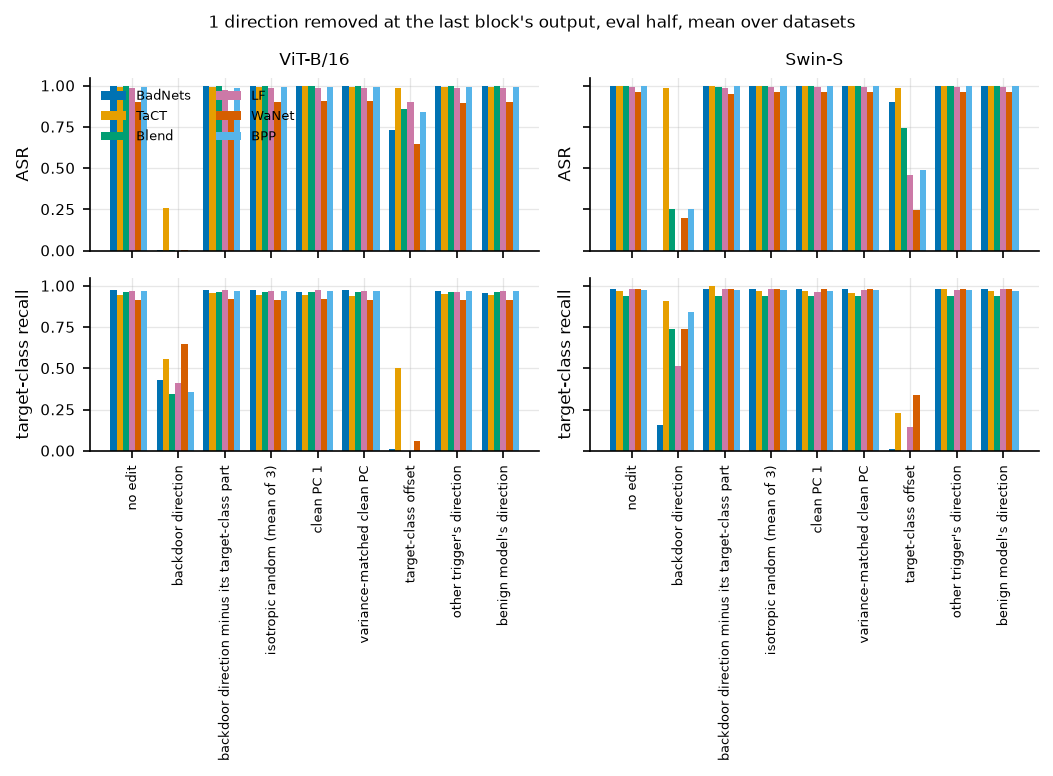

asr         \
                                                              mean    max   
architecture edit                                                           
swin         no edit                                         0.991  1.000   
             backdoor direction                              0.180  1.000   
             backdoor direction minus its target-class part  0.986  1.000   
             isotropic random (mean of 3)                    0.991  1.000   
             clean PC 1                                      0.991  1.000   
             variance-matched clean PC                       0.991  1.000   
             target-class offset                             0.589  1.000   
             other trigger's direction                       0.991  1.000   
             benign model's direction                        0.992  1.000   
vit          no edit                                         0.986  1.000   
             backdoor direction                              0.038  0.698   
             backdoor direction minus its target-class part  0.974  1.000   
             isotropic random (mean of 3)                    0.986  1.000   
             clean PC 1                                      0.987  1.000   
             variance-matched clean PC                       0.986  1.000   
             target-class offset                             0.837  1.000   
             other trigger's direction                       0.985  1.000   
             benign model's direction                        0.986  1.000   

                                                            clean_accuracy  \
                                                                      mean   
architecture edit                                                            
swin         no edit                                                 0.921   
             backdoor direction                                      0.875   
             backdoor direction minus its target-class part          0.920   
             isotropic random (mean of 3)                            0.921   
             clean PC 1                                              0.877   
             variance-matched clean PC                               0.915   
             target-class offset                                     0.921   
             other trigger's direction                               0.917   
             benign model's direction                                0.920   
vit          no edit                                                 0.899   
             backdoor direction                                      0.867   
             backdoor direction minus its target-class part          0.899   
             isotropic random (mean of 3)                            0.899   
             clean PC 1                                              0.848   
             variance-matched clean PC                               0.900   
             target-class offset                                     0.818   
             other trigger's direction                               0.860   
             benign model's direction                                0.899   

                                                                    \
                                                               max   
architecture edit                                                    
swin         no edit                                         0.988   
             backdoor direction                              0.990   
             backdoor direction minus its target-class part  0.990   
             isotropic random (mean of 3)                    0.988   
             clean PC 1                                      0.988   
             variance-matched clean PC                       0.988   
             target-class offset                             0.988   
             other trigger's direction                       0.988   
             benign model's directio

In [26]:
DIRECTION_ABLATIONS = {
    "none": "no edit",
    "direction": "backdoor direction",
    "direction_orthogonal_to_target": "backdoor direction minus its target-class part",
    "random_direction": "isotropic random (mean of 3)",
    "clean_pc1": "clean PC 1",
    "variance_matched_pc": "variance-matched clean PC",
    "target_class_direction": "target-class offset",
    "other_trigger_direction": "other trigger's direction",
    "benign_direction": "benign model's direction",
}
NEURON_RULES = {
    "top_tac": "top TAC",
    "top_direction_coordinates": "top direction coordinates",
    "top_magnitude": "top clean magnitude",
    "random_coordinates": "random",
}


def variant_value(ablation, key, measure):
    variants = ablation["variants"]
    if key == "random_direction":
        value = float(np.mean([variants[f"random_direction_{index}"][measure] for index in range(3)]))
        return value
    if key not in variants or variants[key][measure] is None:
        return np.nan
    value = variants[key][measure]
    return value


def ablation_table(which, keys, measure):
    rows = []
    for _, row in usable(ROWS).iterrows():
        for key in keys:
            rows.append(
                {
                    "run": row["name"],
                    "architecture": row["architecture"],
                    "attack": ATTACK_LABEL[row["attack"]],
                    "edit": key,
                    measure: variant_value(row[which], key, measure),
                }
            )
    frame = pd.DataFrame(rows)
    return frame


def show_edit_bars(which, keys, labels, title):
    figure, axes = plt.subplots(2, 2, figsize=(7.0, 5.2), sharey="row")
    for column, architecture in enumerate(("vit", "swin")):
        for row, measure in enumerate(("asr", "target_recall")):
            axis = axes[row, column]
            frame = ablation_table(which, keys, measure)
            frame = frame[frame["architecture"] == architecture]
            table = frame.pivot_table(index="edit", columns="attack", values=measure).reindex(keys)
            attacks = [ATTACK_LABEL[attack] for attack in ATTACKS if ATTACK_LABEL[attack] in table.columns]
            width = 0.8 / max(len(attacks), 1)
            for offset, attack in enumerate(attacks):
                key = next(name for name, label in ATTACK_LABEL.items() if label == attack)
                axis.bar(np.arange(len(keys)) + offset * width, table[attack], width=width, color=ATTACK_COLOUR[key], label=attack)
            axis.set_xticks(np.arange(len(keys)) + 0.4, labels if row == 1 else [], rotation=90, fontsize=6)
            axis.set_ylabel("ASR" if measure == "asr" else "target-class recall")
            if row == 0:
                axis.set_title(ARCHITECTURE_LABEL[architecture], fontsize=8)
    axes[0, 0].legend(fontsize=6, ncol=2)
    figure.suptitle(title, fontsize=8)
    figure.tight_layout()
    plt.show()


def edit_summary(which, keys, labels):
    frames = [ablation_table(which, keys, measure) for measure in ("asr", "clean_accuracy", "target_recall")]
    merged = frames[0].merge(frames[1], on=["run", "architecture", "attack", "edit"]).merge(frames[2], on=["run", "architecture", "attack", "edit"])
    merged["edit"] = merged["edit"].map(dict(zip(keys, labels)))
    table = merged.groupby(["architecture", "edit"])[["asr", "clean_accuracy", "target_recall"]].agg(["mean", "max"])
    return table.reindex(labels, level=1)


direction_keys = list(DIRECTION_ABLATIONS)
direction_labels = list(DIRECTION_ABLATIONS.values())
show_edit_bars("ablation_final", direction_keys, direction_labels, "1 direction removed at the last block's output, eval half, mean over datasets")
edit_summary("ablation_final", direction_keys, direction_labels).round(3)

The same test on neurons zeroes k coordinates for k in 20, 100 and 300 of 768, chosen 4 ways: by TAC (the backdoor-neuron rule), by the size of the direction's own coordinates (the best a coordinate rule could do if it knew the direction), by mean clean magnitude (ViT carries a few massive activation coordinates, and a top-neuron rule could be picking those) and at random. The random and magnitude rules at every k are the controls.

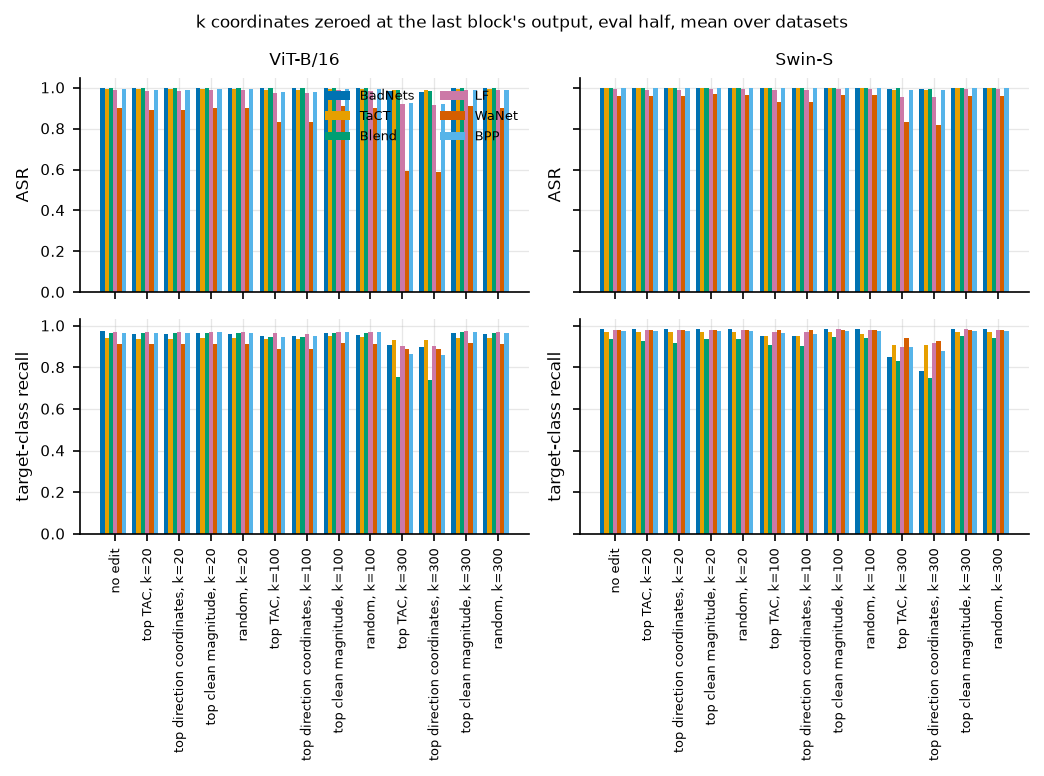

asr      clean_accuracy  \
                                                mean  max           mean   
architecture edit                                                          
swin         no edit                           0.991  1.0          0.921   
             top TAC, k=20                     0.990  1.0          0.921   
             top direction coordinates, k=20   0.990  1.0          0.921   
             top clean magnitude, k=20         0.992  1.0          0.921   
             random, k=20                      0.992  1.0          0.921   
             top TAC, k=100                    0.983  1.0          0.920   
             top direction coordinates, k=100  0.984  1.0          0.921   
             top clean magnitude, k=100        0.992  1.0          0.920   
             random, k=100                     0.992  1.0          0.921   
             top TAC, k=300                    0.955  1.0          0.918   
             top direction coordinates, k=300  0.952  1.0          0.918   
             top clean magnitude, k=300        0.992  1.0          0.913   
             random, k=300                     0.991  1.0          0.920   
vit          no edit                           0.986  1.0          0.899   
             top TAC, k=20                     0.983  1.0          0.900   
             top direction coordinates, k=20   0.983  1.0          0.900   
             top clean magnitude, k=20         0.986  1.0          0.900   
             random, k=20                      0.986  1.0          0.900   
             top TAC, k=100                    0.973  1.0          0.900   
             top direction coordinates, k=100  0.973  1.0          0.899   
             top clean magnitude, k=100        0.987  1.0          0.899   
             random, k=100                     0.985  1.0          0.900   
             top TAC, k=300                    0.924  1.0          0.899   
             top direction coordinates, k=300  0.922  1.0          0.899   
             top clean magnitude, k=300        0.986  1.0          0.888   
             random, k=300                     0.986  1.0          0.900   

                                                     target_recall       
                                                 max          mean  max  
architecture edit                                                        
swin         no edit                           0.988         0.971  1.0  
             top TAC, k=20                     0.988         0.968  1.0  
             top direction coordinates, k=20   0.988         0.967  1.0  
             top clean magnitude, k=20         0.988         0.971  1.0  
             random, k=20                      0.988         0.971  1.0  
             top TAC, k=100                    0.988         0.954  1.0  
             top direction coordinates, k=100  0.988         0.953  1.0  
             top clean magnitude, k=100        0.988         0.973  1.0  
             random, k=100                     0.988         0.971  1.0  
             top TAC, k=300                    0.990         0.885  1.0  
             top direction coordinates, k=300  0.993         0.854  1.0  
             top clean magnitude, k=300        0.988         0.974  1.0  
             random, k=300                     0.988         0.972  1.0  
vit          no edit                           1.000         0.961  1.0  
             top TAC, k=20                     0.997         0.956  1.0  
             top direction coordinates, k=20   0.997         0.956  1.0  
             top clean magnitude, k=20         0.997         0.959  1.0  
             random, k=20                      1.000         0.957  1.0  
             top TAC, k=100                    0.997         0.945  1.0  
             top direction coordinates, k=100  0.997         0.945  1.0  
             top clean magnitude, k=100        0.997         0.961  1.0  
             random, k=100                     1.000         0.958  

In [27]:
neuron_keys = ["none"] + [f"{rule}_{k}" for k in NEURON_COUNTS for rule in NEURON_RULES]
neuron_labels = ["no edit"] + [f"{label}, k={k}" for k in NEURON_COUNTS for label in NEURON_RULES.values()]
show_edit_bars("ablation_final", neuron_keys, neuron_labels, "k coordinates zeroed at the last block's output, eval half, mean over datasets")
edit_summary("ablation_final", neuron_keys, neuron_labels).round(3)

In [28]:
def edit_means(which, key, measure):
    values = ablation_table(which, [key], measure).groupby("architecture")[measure].mean()
    return values


lines = []
for architecture in ("vit", "swin"):
    label = ARCHITECTURE_LABEL[architecture]
    lines.append(
        f"On {label} at the last block, removing the backdoor direction takes mean ASR from "
        f"{edit_means('ablation_final', 'none', 'asr')[architecture]:.3f} to {edit_means('ablation_final', 'direction', 'asr')[architecture]:.3f}, "
        f"and target-class recall from {edit_means('ablation_final', 'none', 'target_recall')[architecture]:.3f} to "
        f"{edit_means('ablation_final', 'direction', 'target_recall')[architecture]:.3f}. "
        f"Removing the target-class offset gives ASR {edit_means('ablation_final', 'target_class_direction', 'asr')[architecture]:.3f} and recall "
        f"{edit_means('ablation_final', 'target_class_direction', 'target_recall')[architecture]:.3f}, while the backdoor direction minus its "
        f"target-class part leaves ASR at {edit_means('ablation_final', 'direction_orthogonal_to_target', 'asr')[architecture]:.3f}. "
        f"The energy-matched clean PC leaves ASR at {edit_means('ablation_final', 'variance_matched_pc', 'asr')[architecture]:.3f}, isotropic random directions at "
        f"{edit_means('ablation_final', 'random_direction', 'asr')[architecture]:.3f}, the other trigger's direction at "
        f"{edit_means('ablation_final', 'other_trigger_direction', 'asr')[architecture]:.3f} and the benign model's direction at "
        f"{edit_means('ablation_final', 'benign_direction', 'asr')[architecture]:.3f}. "
        f"Zeroing the 300 top-TAC neurons leaves ASR at {edit_means('ablation_final', 'top_tac_300', 'asr')[architecture]:.3f}, "
        f"300 random neurons at {edit_means('ablation_final', 'random_coordinates_300', 'asr')[architecture]:.3f} and the 300 largest-magnitude neurons at "
        f"{edit_means('ablation_final', 'top_magnitude_300', 'asr')[architecture]:.3f}."
    )
display(Markdown(" ".join(lines)))

On ViT-B/16 at the last block, removing the backdoor direction takes mean ASR from 0.986 to 0.038, and target-class recall from 0.961 to 0.436. Removing the target-class offset gives ASR 0.837 and recall 0.079, while the backdoor direction minus its target-class part leaves ASR at 0.974. The energy-matched clean PC leaves ASR at 0.986, isotropic random directions at 0.986, the other trigger's direction at 0.985 and the benign model's direction at 0.986. Zeroing the 300 top-TAC neurons leaves ASR at 0.924, 300 random neurons at 0.986 and the 300 largest-magnitude neurons at 0.986. On Swin-S at the last block, removing the backdoor direction takes mean ASR from 0.991 to 0.180, and target-class recall from 0.971 to 0.613. Removing the target-class offset gives ASR 0.589 and recall 0.105, while the backdoor direction minus its target-class part leaves ASR at 0.986. The energy-matched clean PC leaves ASR at 0.991, isotropic random directions at 0.991, the other trigger's direction at 0.991 and the benign model's direction at 0.992. Zeroing the 300 top-TAC neurons leaves ASR at 0.955, 300 random neurons at 0.991 and the 300 largest-magnitude neurons at 0.992.

The table checks 2 of the controls' premises. The first 3 columns give the share of the top-k TAC coordinates that are also top-k clean-magnitude coordinates. The next 3 give the clean variance along the backdoor direction, along its variance-matched PC and along clean PC 1, which shows that the energy match is close and that PC 1 carries far more. The last 3 give the cosine between the backdoor direction and the target-class offset, the benign model's direction and the other trigger's direction. A cosine near 0 means the control is a different direction, not a noisy copy.

In [29]:
overlap_rows = []
for _, row in usable(ROWS).iterrows():
    for which in ("ablation_final", "ablation_middle"):
        entry = row[which]
        overlap_rows.append(
            {
                "architecture": row["architecture"],
                "depth": "last block" if which == "ablation_final" else "2/3 depth",
                **{f"top {k} TAC in top {k} magnitude": entry["top_tac_magnitude_overlap"][str(k)] for k in NEURON_COUNTS},
                "clean variance, backdoor direction": entry["clean_variance_along"]["direction"],
                "clean variance, variance-matched PC": entry["clean_variance_along"]["variance_matched_pc"],
                "clean variance, clean PC 1": entry["clean_variance_along"]["clean_pc1"],
                "cos(target offset, backdoor)": entry["cosine_to_direction"]["target_class_direction"],
                "cos(variance-matched PC, backdoor)": entry["cosine_to_direction"]["variance_matched_pc"],
                "cos(benign, backdoor)": entry["cosine_to_direction"].get("benign_direction", np.nan),
                "cos(other trigger, backdoor)": entry["cosine_to_direction"]["other_trigger_direction"],
            }
        )
pd.DataFrame(overlap_rows).groupby(["architecture", "depth"]).mean().round(3)

top 20 TAC in top 20 magnitude  \
architecture depth                                        
swin         2/3 depth                            0.224   
             last block                           0.250   
vit          2/3 depth                            0.038   
             last block                           0.074   

                         top 100 TAC in top 100 magnitude  \
architecture depth                                          
swin         2/3 depth                              0.351   
             last block                             0.253   
vit          2/3 depth                              0.168   
             last block                             0.197   

                         top 300 TAC in top 300 magnitude  \
architecture depth                                          
swin         2/3 depth                              0.803   
             last block                             0.491   
vit          2/3 depth                              0.459   
             last block                             0.470   

                         clean variance, backdoor direction  \
architecture depth                                            
swin         2/3 depth                                1.503   
             last block                              39.779   
vit          2/3 depth                                0.876   
             last block                               4.752   

                         clean variance, variance-matched PC  \
architecture depth                                             
swin         2/3 depth                                 1.524   
             last block                               39.669   
vit          2/3 depth                                 0.872   
             last block                                2.990   

                         clean variance, clean PC 1  \
architecture depth                                    
swin         2/3 depth                       15.321   
             last block                     194.204   
vit          2/3 depth                        4.765   
             last block                      45.887   

                         cos(target offset, backdoor)  \
architecture depth                                      
swin         2/3 depth                          0.106   
             last block                         0.637   
vit          2/3 depth                          0.201   
             last block                         0.757   

                         cos(variance-matched PC, backdoor)  \
architecture depth                                            
swin         2/3 depth                               -0.012   
             last block                               0.006   
vit          2/3 depth                               -0.006   
             last block                               0.016   

                         cos(benign, backdoor)  cos(other trigger, backdoor)  
architecture depth                                                            
swin         2/3 depth                   0.415                         0.028  
             last block                  0.069                        -0.044  
vit          2/3 depth                   0.335                         0.029  
             last block                  0.131                         0.078

Target-class recall is 1 class. Per-class recall over all classes present in the eval half (the eligible pairs and the target images) shows whether an edit costs every class a little or 1 class a lot. The table gives, per architecture and edit, the change in target-class recall, the mean change over the other classes and the worst single-class change, each averaged over runs.

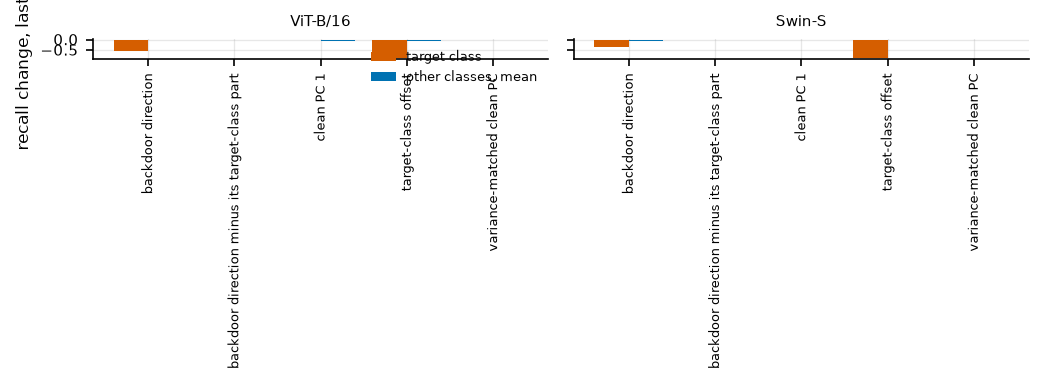

target recall change  \
architecture edit                                                                   
swin         backdoor direction                                            -0.357   
             backdoor direction minus its target-class part                 0.002   
             clean PC 1                                                    -0.003   
             target-class offset                                           -0.865   
             variance-matched clean PC                                     -0.001   
vit          backdoor direction                                            -0.524   
             backdoor direction minus its target-class part                 0.004   
             clean PC 1                                                     0.001   
             target-class offset                                           -0.881   
             variance-matched clean PC                                     -0.001   

                                                             mean other-class change  \
architecture edit                                                                      
swin         backdoor direction                                               -0.046   
             backdoor direction minus its target-class part                   -0.001   
             clean PC 1                                                       -0.042   
             target-class offset                                               0.000   
             variance-matched clean PC                                        -0.005   
vit          backdoor direction                                               -0.030   
             backdoor direction minus its target-class part                    0.001   
             clean PC 1                                                       -0.047   
             target-class offset                                              -0.079   
             variance-matched clean PC                                         0.001   

                                                             worst other-class change  
architecture edit                                                                      
swin         backdoor direction                                                -0.239  
             backdoor direction minus its target-class part                    -0.169  
             clean PC 1                                                        -0.411  
             target-class offset                                               -0.080  
             variance-matched clean PC                                         -0.229  
vit          backdoor direction                                                -0.071  
             backdoor direction minus its target-class part                    -0.014  
             clean PC 1                                                        -0.228  
             target-class offset                                               -0.129  
             variance-matched clean PC                                         -0.062

In [30]:
def recall_changes(name, which_layer, key):
    record = load_run(name)
    variants = record["ablation"][which_layer]["variants"]
    before = np.asarray([np.nan if value is None else value for value in variants["none"]["per_class_recall"]])
    after = np.asarray([np.nan if value is None else value for value in variants[key]["per_class_recall"]])
    change = after - before
    return change, record["run"]["target"]


recall_rows = []
for _, row in usable(ROWS).iterrows():
    record = load_run(row["name"])
    final = str(record["num_blocks"])
    for key in ("direction", "direction_orthogonal_to_target", "target_class_direction", "variance_matched_pc", "clean_pc1"):
        change, target = recall_changes(row["name"], final, key)
        others = np.delete(change, target)
        recall_rows.append(
            {
                "architecture": row["architecture"],
                "edit": DIRECTION_ABLATIONS[key],
                "target recall change": change[target],
                "mean other-class change": np.nanmean(others),
                "worst other-class change": np.nanmin(others),
            }
        )
recall_means = pd.DataFrame(recall_rows).groupby(["architecture", "edit"]).mean()
figure, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), sharey=True)
for axis, architecture in zip(axes, ("vit", "swin")):
    subset = recall_means.loc[architecture]
    positions = np.arange(len(subset))
    axis.bar(positions - 0.2, subset["target recall change"], width=0.4, color=PALETTE[4], label="target class")
    axis.bar(positions + 0.2, subset["mean other-class change"], width=0.4, color=PALETTE[0], label="other classes, mean")
    axis.set_xticks(positions, subset.index, rotation=90, fontsize=6)
    axis.set_title(ARCHITECTURE_LABEL[architecture], fontsize=7)
axes[0].set_ylabel("recall change, last block")
axes[0].legend(fontsize=6)
figure.tight_layout()
plt.show()
recall_means.round(3)

In [31]:
recall_frame = pd.DataFrame(recall_rows).groupby(["architecture", "edit"]).mean()
display(
    Markdown(
        "Removing the backdoor direction at the last block costs the target class "
        f"{-recall_frame.loc[('vit', 'backdoor direction'), 'target recall change']:.3f} of its recall on ViT and "
        f"{-recall_frame.loc[('swin', 'backdoor direction'), 'target recall change']:.3f} on Swin, while the other classes move by "
        f"{recall_frame.loc[('vit', 'backdoor direction'), 'mean other-class change']:+.3f} and "
        f"{recall_frame.loc[('swin', 'backdoor direction'), 'mean other-class change']:+.3f} on average. "
        "The edit is specific to 1 class, and that class is the target."
    )
)

Removing the backdoor direction at the last block costs the target class 0.524 of its recall on ViT and 0.357 on Swin, while the other classes move by -0.030 and -0.046 on average. The edit is specific to 1 class, and that class is the target.

The controls change how the ablation reads. Removing the backdoor direction at the last block does take ASR to near 0 while every energy-matched, random, other-trigger and benign-direction control leaves it untouched, so the direction is necessary and no generic high-energy direction is. The same edit also removes about half of the target class's own recall, and the backdoor direction with its target-class part projected out leaves ASR where it was. At the last block the backdoor direction is therefore mostly a push along the target class's readout axis, and deleting it deletes part of the target class with it. The rank-1 removal is necessary for the backdoor but not specific to it, which is what the audit suspected of the earlier CIFAR-10 result.

The neuron removals give the complementary answer. Zeroing 300 of 768 top-TAC coordinates leaves most of the backdoor in place on both architectures, exactly as 300 random or 300 largest-magnitude coordinates do. What no coordinate rule removes, 1 direction does, so in the last block the backdoor is a direction in a rotated basis rather than a set of neurons. That this direction coincides with the target's readout axis is the measured qualification.

Removing the direction at the last block leaves no block to repair it. At 2/3 of the depth (block 8 on ViT, block 16 on Swin) the later blocks can rewrite what was removed, so this repeat asks whether the backdoor is a single late readout or is rebuilt from earlier layers. On Swin block 16 sits in stage 3, whose stream has 384 coordinates, so zeroing 300 of them removes most of the stream and the neuron rows at k=300 there measure a broken model, as their clean accuracy shows.

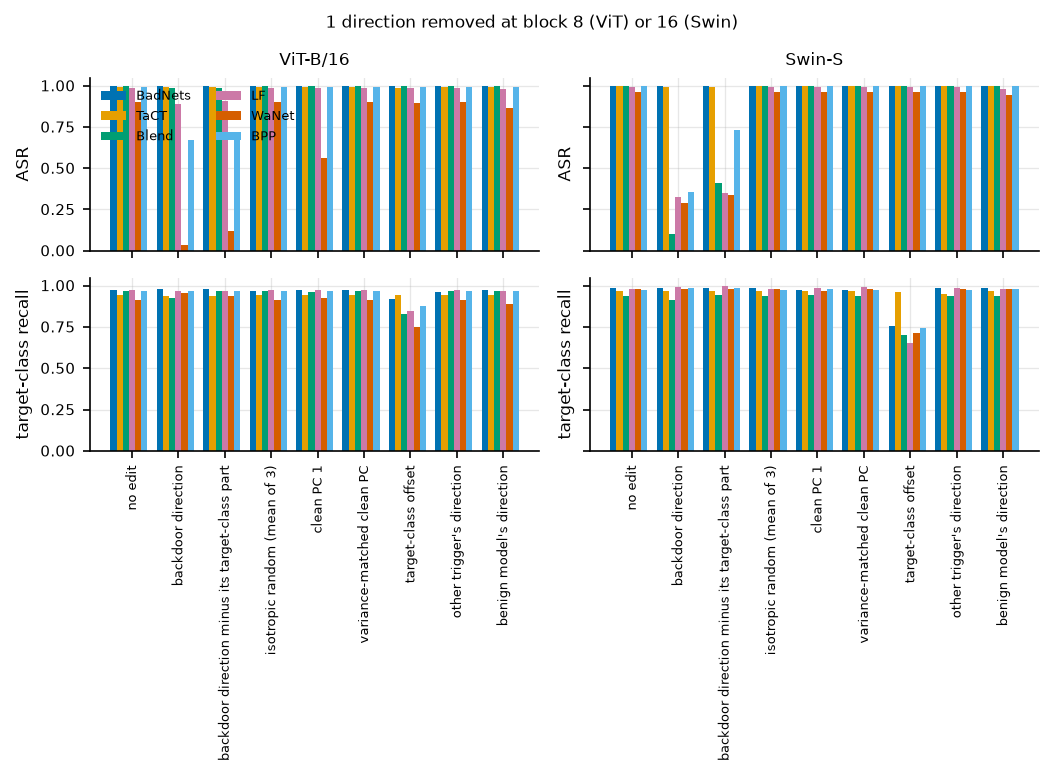

asr         \
                                                              mean    max   
architecture edit                                                           
swin         no edit                                         0.991  1.000   
             backdoor direction                              0.442  1.000   
             backdoor direction minus its target-class part  0.585  1.000   
             isotropic random (mean of 3)                    0.992  1.000   
             clean PC 1                                      0.992  1.000   
             variance-matched clean PC                       0.992  1.000   
             target-class offset                             0.991  1.000   
             other trigger's direction                       0.991  1.000   
             benign model's direction                        0.986  1.000   
vit          no edit                                         0.986  1.000   
             backdoor direction                              0.820  1.000   
             backdoor direction minus its target-class part  0.841  1.000   
             isotropic random (mean of 3)                    0.986  1.000   
             clean PC 1                                      0.954  1.000   
             variance-matched clean PC                       0.986  1.000   
             target-class offset                             0.983  1.000   
             other trigger's direction                       0.986  1.000   
             benign model's direction                        0.980  1.000   
swin         no edit                                         0.991  1.000   
             top TAC, k=20                                   0.980  1.000   
             top direction coordinates, k=20                 0.981  1.000   
             top clean magnitude, k=20                       0.993  1.000   
             random, k=20                                    0.991  1.000   
             top TAC, k=100                                  0.890  1.000   
             top direction coordinates, k=100                0.892  1.000   
             top clean magnitude, k=100                      0.995  1.000   
             random, k=100                                   0.992  1.000   
             top TAC, k=300                                  0.257  0.973   
             top direction coordinates, k=300                0.222  1.000   
             top clean magnitude, k=300                      0.834  1.000   
             random, k=300                                   0.989  1.000   
vit          no edit                                         0.986  1.000   
             top TAC, k=20                                   0.980  1.000   
             top direction coordinates, k=20                 0.980  1.000   
             top clean magnitude, k=20                       0.987  1.000   
             random, k=20                                    0.986  1.000   
             top TAC, k=100                                  0.958  1.000   
             top direction coordinates, k=100                0.958  1.000   
             top clean magnitude, k=100                      0.886  1.000   
             random, k=100                                   0.983  1.000   
             top TAC, k=300                                  0.854  1.000   
             top direction coordinates, k=300                0.856  1.000   
             top clean magnitude, k=300                      0.726  1.000   
             random, k=300                                   0.979  1.000   

                                                            clean_accuracy  \
                                                                      mean   
architecture edit                                                            
swin         no edit                                                 0.921   
             backdoor direction                                      0.920   
             backdoor direction minus its target-clas

In [32]:
show_edit_bars("ablation_middle", direction_keys, direction_labels, "1 direction removed at block 8 (ViT) or 16 (Swin)")
pd.concat(
    [
        edit_summary("ablation_middle", direction_keys, direction_labels),
        edit_summary("ablation_middle", neuron_keys, neuron_labels),
    ]
).round(3)

In [33]:
display(
    Markdown(
        f"At 2/3 of the depth, removing the backdoor direction leaves mean ASR at "
        f"{edit_means('ablation_middle', 'direction', 'asr')['vit']:.3f} on ViT and {edit_means('ablation_middle', 'direction', 'asr')['swin']:.3f} on Swin, "
        f"and 300 top-TAC neurons leave it at {edit_means('ablation_middle', 'top_tac_300', 'asr')['vit']:.3f} and "
        f"{edit_means('ablation_middle', 'top_tac_300', 'asr')['swin']:.3f}. "
        "A hypothesis, not tested here: the later blocks rebuild the direction from the patch tokens that still carry the trigger, "
        "as the attention readout of step 2 suggests. Testing it would need the removal repeated on the patch tokens alone."
    )
)

At 2/3 of the depth, removing the backdoor direction leaves mean ASR at 0.820 on ViT and 0.442 on Swin, and 300 top-TAC neurons leave it at 0.854 and 0.257. A hypothesis, not tested here: the later blocks rebuild the direction from the patch tokens that still carry the trigger, as the attention readout of step 2 suggests. Testing it would need the removal repeated on the patch tokens alone.

Removal tests necessity. Steering tests sufficiency: the backdoor direction is added to clean eval images at the same block and the table gives the share now predicted as the target. Every other added direction is rescaled to the backdoor direction's norm, so only the orientation differs between columns. On benign controls, whose runs are included in the pooled rows only as the "benign model's direction" column of their backdoored twin, steering with the benign model's own direction is a separate reading in the benign runs' JSON.

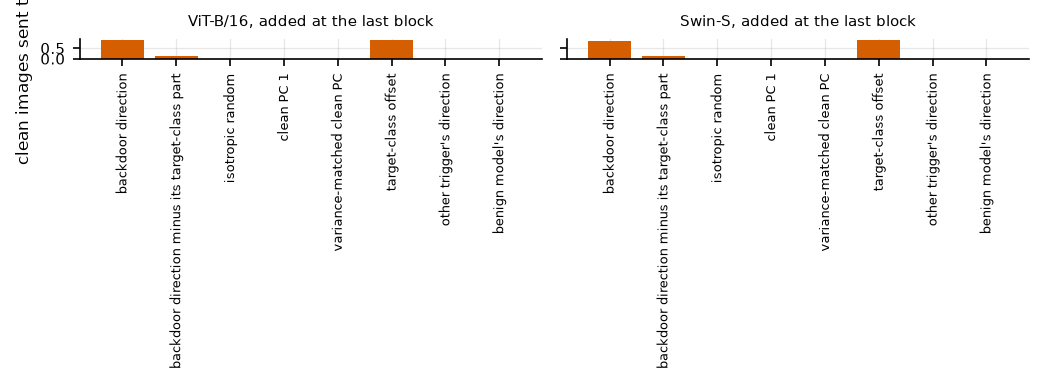

added direction          backdoor direction  \
architecture depth                            
swin         2/3 depth                0.722   
             last block               0.864   
vit          2/3 depth                0.158   
             last block               0.924   

added direction          backdoor direction minus its target-class part  \
architecture depth                                                        
swin         2/3 depth                                            0.720   
             last block                                           0.151   
vit          2/3 depth                                            0.149   
             last block                                           0.148   

added direction          isotropic random  clean PC 1  \
architecture depth                                      
swin         2/3 depth              0.005       0.014   
             last block             0.002       0.001   
vit          2/3 depth              0.003       0.009   
             last block             0.003       0.003   

added direction          variance-matched clean PC  target-class offset  \
architecture depth                                                        
swin         2/3 depth                       0.003                0.524   
             last block                      0.001                0.904   
vit          2/3 depth                       0.003                0.024   
             last block                      0.002                0.916   

added direction          other trigger's direction  benign model's direction  
architecture depth                                                            
swin         2/3 depth                       0.038                     0.312  
             last block                      0.001                     0.004  
vit          2/3 depth                       0.003                     0.010  
             last block                      0.012                     0.006

In [34]:
STEER_LABEL = {
    "direction": "backdoor direction",
    "direction_orthogonal_to_target": "backdoor direction minus its target-class part",
    "random_direction_0": "isotropic random",
    "clean_pc1": "clean PC 1",
    "variance_matched_pc": "variance-matched clean PC",
    "target_class_direction": "target-class offset",
    "other_trigger_direction": "other trigger's direction",
    "benign_direction": "benign model's direction",
}
steer_rows = []
for _, row in usable(ROWS).iterrows():
    for which, depth in (("ablation_final", "last block"), ("ablation_middle", "2/3 depth")):
        steering = row[which]["steer_clean_to_target"]
        for key, label in STEER_LABEL.items():
            steer_rows.append(
                {
                    "architecture": row["architecture"],
                    "depth": depth,
                    "added direction": label,
                    "clean sent to target": steering.get(key, np.nan),
                }
            )
steer_frame = pd.DataFrame(steer_rows)
figure, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), sharey=True)
for axis, architecture in zip(axes, ("vit", "swin")):
    means = steer_frame[(steer_frame["architecture"] == architecture) & (steer_frame["depth"] == "last block")].groupby("added direction")["clean sent to target"].mean().reindex(list(STEER_LABEL.values()))
    axis.bar(range(len(means)), means.values, color=PALETTE[4])
    axis.set_xticks(range(len(means)), means.index, rotation=90, fontsize=6)
    axis.set_title(f"{ARCHITECTURE_LABEL[architecture]}, added at the last block", fontsize=7)
axes[0].set_ylabel("clean images sent to target")
figure.tight_layout()
plt.show()
steer_frame.pivot_table(index=["architecture", "depth"], columns="added direction", values="clean sent to target")[list(STEER_LABEL.values())].round(3)

In [35]:
steer_means = steer_frame.pivot_table(index=["architecture", "depth"], columns="added direction", values="clean sent to target")
display(
    Markdown(
        "Adding the backdoor direction at the last block sends "
        f"{steer_means.loc[('vit', 'last block'), 'backdoor direction']:.3f} of clean images to the target on ViT and "
        f"{steer_means.loc[('swin', 'last block'), 'backdoor direction']:.3f} on Swin. The target-class offset at the same norm sends "
        f"{steer_means.loc[('vit', 'last block'), 'target-class offset']:.3f} and {steer_means.loc[('swin', 'last block'), 'target-class offset']:.3f}, "
        f"the benign model's direction {steer_means.loc[('vit', 'last block'), 'benign model' + chr(39) + 's direction']:.3f} and "
        f"{steer_means.loc[('swin', 'last block'), 'benign model' + chr(39) + 's direction']:.3f}, and an isotropic random direction "
        f"{steer_means.loc[('vit', 'last block'), 'isotropic random']:.3f} and {steer_means.loc[('swin', 'last block'), 'isotropic random']:.3f}."
    )
)

Adding the backdoor direction at the last block sends 0.924 of clean images to the target on ViT and 0.864 on Swin. The target-class offset at the same norm sends 0.916 and 0.904, the benign model's direction 0.006 and 0.004, and an isotropic random direction 0.003 and 0.002.

## Step 5, latent geometry at the head

The head input is the space the final linear layer reads. The scatter projects the eval half of 3 populations there: clean eligible images (blue), the same images triggered (orange) and clean images of the target class (green). PCA and UMAP are fitted on the fit half of the same 3 populations and applied to the eval half (`embedding_record`), so the picture cannot show structure the projection found in its own points. UMAP uses 15 neighbors and a minimum distance of 0.1, and like any UMAP it keeps neighborhoods and distorts distances, so only which points share a cluster is readable. The last panel of each row is the benign control of the first model, shown the same trigger.

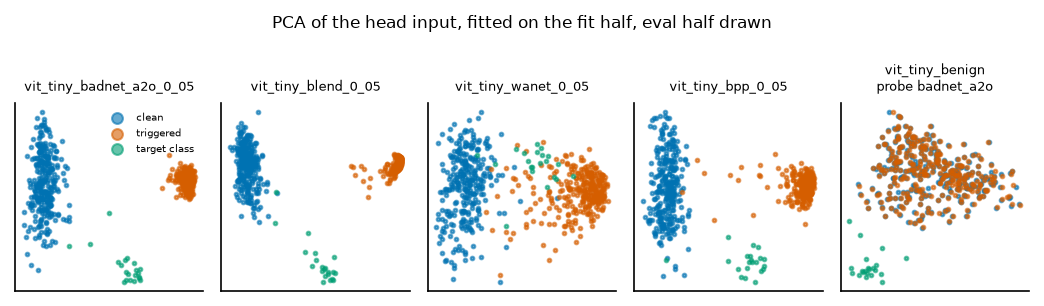

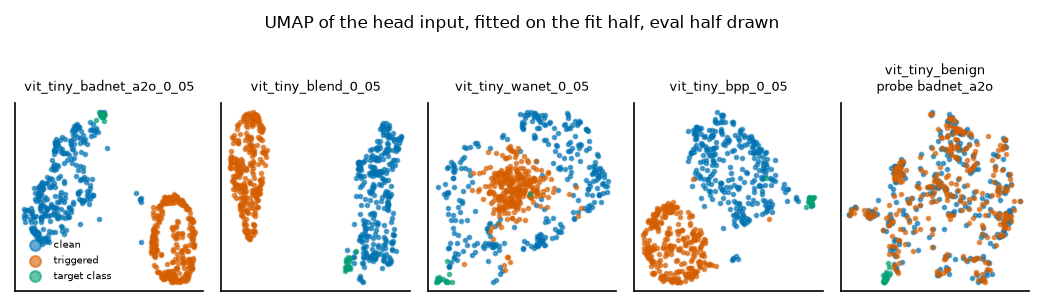

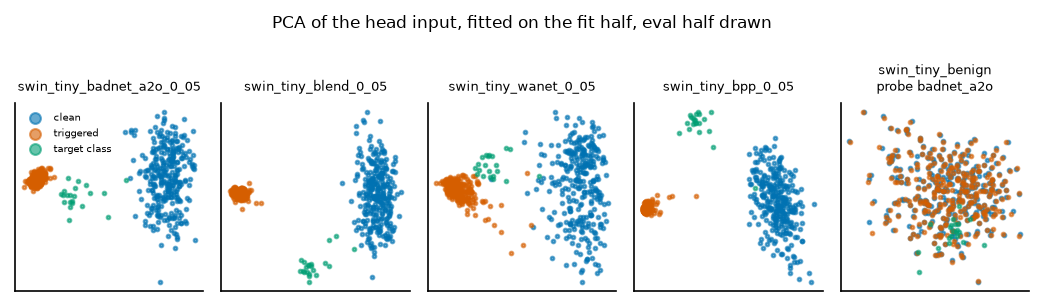

In [36]:
POPULATION_COLOUR = {"clean": PALETTE[0], "triggered": PALETTE[4], "target_class": PALETTE[2]}


def show_embeddings(names, method):
    figure, axes = plt.subplots(1, len(names), figsize=(7.0, 2.0))
    for axis, name in zip(axes, names):
        record = load_embedding(name)
        points = np.asarray(record[method])
        populations = np.asarray(record["populations"])
        for population, colour in POPULATION_COLOUR.items():
            mask = populations == population
            axis.scatter(points[mask, 0], points[mask, 1], s=3, alpha=0.6, color=colour, label=population.replace("_", " "))
        axis.set_title(name.replace("__", "\nprobe "), fontsize=6)
        axis.set_xticks([])
        axis.set_yticks([])
    axes[0].legend(fontsize=5, markerscale=3)
    figure.suptitle(f"{method.upper()} of the head input, fitted on the fit half, eval half drawn", fontsize=8)
    figure.tight_layout()
    plt.show()


latent_names = [featured_run("vit", attack) for attack in ("badnet_a2o", "blend", "wanet", "bpp")]
show_embeddings(latent_names + [control_name(latent_names[0])], "pca")
show_embeddings(latent_names + [control_name(latent_names[0])], "umap")
swin_names = [featured_run("swin", attack) for attack in ("badnet_a2o", "blend", "wanet", "bpp")]
show_embeddings(swin_names + [control_name(swin_names[0])], "pca")

If the backdoor direction is how the model sends triggered images to the target, it should point along the target's row of the classifier weight. `readout_alignment` centers the weight rows over classes, $\tilde w_c = w_c - \frac{1}{C}\sum_{c'} w_{c'}$, because adding 1 vector to every row shifts every logit equally and changes no prediction. It then reports the cosine between the head-input backdoor direction and the target's centered row, the largest cosine with any other row and the rank of the target among the logit shifts $\tilde W r$. A random direction's cosine has a standard deviation of about $1/\sqrt{768} = 0.036$.

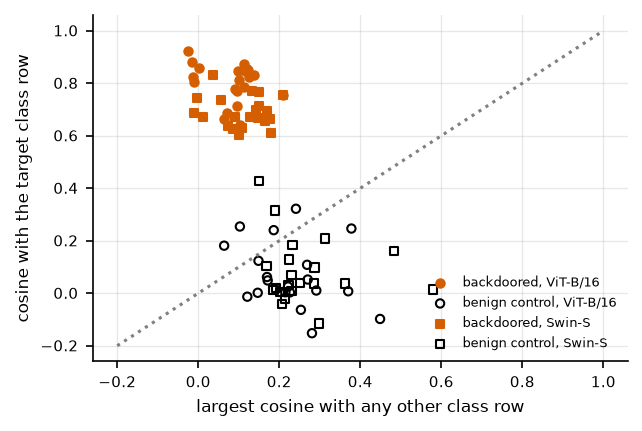

cosine_target_row                \
                                         mean    min    max   
architecture group                                            
swin         backdoored                 0.691  0.603  0.832   
             benign control             0.082 -0.115  0.428   
vit          backdoored                 0.801  0.641  0.922   
             benign control             0.068 -0.152  0.322   

                            max_cosine_other_row                \
                                            mean    min    max   
architecture group                                               
swin         backdoored                    0.109 -0.009  0.209   
             benign control                0.262  0.151  0.579   
vit          backdoored                    0.081 -0.025  0.210   
             benign control                0.229  0.064  0.449   

                            target_logit_rank           
                                         mean min  max  
architecture group                                      
swin         backdoored                  1.00   1    1  
             benign control             23.81   1   93  
vit          backdoored                  1.00   1    1  
             benign control             32.25   1  115

In [37]:
figure, axis = plt.subplots(figsize=(4.6, 3.0))
for architecture, marker in (("vit", "o"), ("swin", "s")):
    rows = ROWS[ROWS["architecture"] == architecture]
    backdoored = usable(rows)
    benign = rows[rows["benign"]]
    axis.scatter(backdoored["max_cosine_other_row"], backdoored["cosine_target_row"], marker=marker, s=16, color=PALETTE[4], label=f"backdoored, {ARCHITECTURE_LABEL[architecture]}")
    axis.scatter(benign["max_cosine_other_row"], benign["cosine_target_row"], marker=marker, s=16, facecolors="none", edgecolors="black", label=f"benign control, {ARCHITECTURE_LABEL[architecture]}")
axis.plot([-0.2, 1], [-0.2, 1], color="grey", linestyle=":")
axis.set_xlabel("largest cosine with any other class row")
axis.set_ylabel("cosine with the target class row")
axis.legend(fontsize=6)
plt.show()
readout = ROWS.assign(group=np.where(ROWS["benign"], "benign control", "backdoored"))
readout = readout[readout["excluded"].isna()]
readout.groupby(["architecture", "group"])[["cosine_target_row", "max_cosine_other_row", "target_logit_rank"]].agg(["mean", "min", "max"]).round(3)

In [38]:
readout_backdoored = usable(ROWS)
readout_benign = ROWS[ROWS["benign"]]
display(
    Markdown(
        f"The head-input backdoor direction has a median cosine of {readout_backdoored['cosine_target_row'].median():.3f} with the target's "
        f"centered weight row (range {readout_backdoored['cosine_target_row'].min():.3f} to {readout_backdoored['cosine_target_row'].max():.3f}), "
        f"and the target has the largest logit shift on {int((readout_backdoored['target_logit_rank'] == 1).sum())} of {len(readout_backdoored)} runs. "
        f"On the benign controls the same cosine has a median of {readout_benign['cosine_target_row'].median():.3f}. "
        "At the head, the backdoor is the target class's own readout direction."
    )
)

The head-input backdoor direction has a median cosine of 0.749 with the target's centered weight row (range 0.603 to 0.922), and the target has the largest logit shift on 42 of 42 runs. On the benign controls the same cosine has a median of 0.037. At the head, the backdoor is the target class's own readout direction.

## Step 6, differences by attack category and architecture

The table collects the readings of steps 3 to 5 per category, attack and architecture, each averaged over datasets. The columns say when the direction appears, how coherent it is, how well it and the best neuron separate and what removing it or 300 top neurons does.

In [39]:
category_rows = []
for _, row in usable(ROWS).iterrows():
    record = load_run(row["name"])
    final = row["ablation_final"]
    category_rows.append(
        {
            "category": row["category"],
            "attack": ATTACK_LABEL[row["attack"]],
            "architecture": row["architecture"],
            "asr": row["asr"],
            "onset depth share": record["onset_layer"] / record["num_blocks"],
            "final CKA": row["final_cka"],
            "direction share": row["final_direction_share"],
            "participation": row["final_participation"],
            "direction AUROC": row["direction_eval_auroc"],
            "best neuron AUROC": row["best_neuron_eval_auroc"],
            "ASR, direction removed": final["variants"]["direction"]["asr"],
            "ASR, variance-matched PC removed": final["variants"]["variance_matched_pc"]["asr"],
            "ASR, top 300 TAC removed": final["variants"]["top_tac_300"]["asr"],
            "target recall, direction removed": final["variants"]["direction"]["target_recall"],
            "cos target row": row["cosine_target_row"],
        }
    )
category_frame = pd.DataFrame(category_rows)
category_frame.groupby(["category", "attack", "architecture"]).mean(numeric_only=True).round(3)

asr  onset depth share  final CKA  \
category     attack  architecture                                        
blend        Blend   swin          1.000              0.208      0.158   
                     vit           1.000              0.542      0.223   
             LF      swin          0.991              0.448      0.118   
                     vit           0.984              0.688      0.257   
patch        BadNets swin          1.000              0.750      0.494   
                     vit           1.000              0.771      0.430   
             TaCT    swin          0.999              0.958      0.882   
                     vit           0.994              0.917      0.949   
quantization BPP     swin          0.999              0.344      0.088   
                     vit           0.989              0.625      0.299   
warp         WaNet   swin          0.964              0.729      0.210   
                     vit           0.903              0.583      0.395   

                                   direction share  participation  \
category     attack  architecture                                   
blend        Blend   swin                    0.671        136.566   
                     vit                     0.616        289.834   
             LF      swin                    0.736        104.673   
                     vit                     0.680        287.163   
patch        BadNets swin                    0.601        117.668   
                     vit                     0.590        278.414   
             TaCT    swin                    0.981        262.644   
                     vit                     0.984        295.565   
quantization BPP     swin                    0.720         58.284   
                     vit                     0.722        285.018   
warp         WaNet   swin                    0.759         21.705   
                     vit                     0.701        285.994   

                                   direction AUROC  best neuron AUROC  \
category     attack  architecture                                       
blend        Blend   swin                    1.000              1.000   
                     vit                     1.000              0.999   
             LF      swin                    1.000              0.999   
                     vit                     1.000              0.994   
patch        BadNets swin                    1.000              1.000   
                     vit                     1.000              0.998   
             TaCT    swin                    1.000              1.000   
                     vit                     1.000              1.000   
quantization BPP     swin                    1.000              1.000   
                     vit                     1.000              0.997   
warp         WaNet   swin                    0.999              0.994   
                     vit                     0.996              0.983   

                                   ASR, direction removed  \
category     attack  architecture                           
blend        Blend   swin                           0.250   
                     vit                            0.002   
             LF      swin                           0.000   
                     vit                            0.001   
patch        BadNets swin                           0.000   
                     vit                            0.002   
             TaCT    swin                           0.987   
                     vit                            0.257   
quantization BPP     swin                           0.250   
                     vit                            0.001   
warp         WaNet   swin                           0.196   
                     vit                            0.004   

                                   ASR, variance-matched PC removed  \
category     attack  architecture                                     
blend        

In [40]:
display(
    Markdown(
        "The table is the summary of the walkthrough per category. The steps above name the model subset and the function behind each column."
    )
)

The table is the summary of the walkthrough per category. The steps above name the model subset and the function behind each column.

## Limits

Every run uses 1 poisoning rate per cell and seed 0 only, so a difference between 2 datasets of the same attack can be a difference between 2 training runs. The panel has no frequency-category model until the SIG sidecars are fixed, no Label-Consistent or Adaptive-Blend model and no all-to-all model. The forward passes run in bfloat16, so TAC and small direction norms carry a rounding floor, which is why every curve is read against a benign control at the same precision. Ablation zeroes a direction or a coordinate, which moves the activation off its clean distribution, and a mean ablation would cost clean accuracy differently. The benign-model direction is taken from a separately trained model whose coordinates share only their ImageNet initialization with the backdoored model's, so its cosine to the backdoor direction is a lower bound on how similar the 2 input responses are.